# Swissgrid single-price — Analysis
Import and exploration of control area balance data (2025 and 2026).

In [103]:
import pandas as pd
import numpy as np

## Import CSV Files

In [104]:
df_2025 = pd.read_csv(
    'control-area-balance-2025.csv',
    sep=';',
    decimal='.',
    parse_dates=['Date Time'],
    dayfirst=True
)

df_2026 = pd.read_csv(
    'control-area-balance-2026.csv',
    sep=';',
    decimal='.',
    parse_dates=['Date Time [UTC]'],
    dayfirst=True
)

# Harmonise datetime column name
df_2026 = df_2026.rename(columns={'Date Time [UTC]': 'Date Time'})

# Convert df_2026 datetime from UTC to UTC+01:00 and remove timezone info to match df_2025 format
df_2026['Date Time'] = pd.to_datetime(df_2026['Date Time'], utc=True).dt.tz_convert('UTC+01:00').dt.tz_localize(None)

print('2025:', df_2025.shape)
print('2026:', df_2026.shape)

2025: (35040, 17)
2026: (11516, 13)


## Overview — 2025

In [105]:
df_2025.head()

,Date Time,Abgedeckte Bedarf der aFRR+,Abgedeckte Bedarf der aFRR-,NRV+ (Import),NRV- (Export),Abgedeckte Bedarf der SA mFRR+,Abgedeckte Bedarf der SA mFRR-,Abgedeckte Bedarf der DA mFRR+,Abgedeckte Bedarf der DA mFRR-,Abgedeckte Bedarf der RR+,Abgedeckte Bedarf der RR-,FRCE+ (Import),FRCE- (Export),Total System Imbalance (Positiv = long / Negativ = short),AE-Preis long,AE-Preis short,AE-Preis per 2026
0,2025-01-01 00:00:00,73.289931,-0.117459,13.952684,-0.983004,177,0,0,0,30,0,13.686001,-8.231586,-298.596568,3.08,32.98,29.48
1,2025-01-01 00:15:00,114.721267,0.000000,9.956801,0.000000,177,0,0,0,30,0,9.912107,-12.023120,-329.567054,8.75,62.12,55.98
2,2025-01-01 00:30:00,65.166966,0.000000,21.596209,0.000000,83,0,0,0,30,0,7.694811,-8.659428,-198.798558,8.75,29.16,26.01
3,2025-01-01 00:45:00,28.054604,-0.278183,7.496333,-7.985104,142,0,0,0,30,0,11.687581,-10.503181,-200.472050,0.20,23.46,20.83
4,2025-01-01 01:00:00,90.402284,0.000000,67.342617,-1.121544,155,0,0,0,30,0,13.064763,-11.532434,-343.155686,8.39,36.21,32.42


In [106]:
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 17 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   Date Time                                                  35040 non-null  datetime64[ns]
 1   Abgedeckte Bedarf der aFRR+                                35040 non-null  float64       
 2   Abgedeckte Bedarf der aFRR-                                35040 non-null  float64       
 3   NRV+ (Import)                                              35040 non-null  float64       
 4   NRV- (Export)                                              35040 non-null  float64       
 5   Abgedeckte Bedarf der SA mFRR+                             35040 non-null  int64         
 6   Abgedeckte Bedarf der SA mFRR-                             35040 non-null  int64         
 7   Abgedeckte Bedarf der DA mFRR+ 

## Overview — 2026

In [107]:
df_2026.head()

,Date Time,Abgedeckte Bedarf der aFRR+,Abgedeckte Bedarf der aFRR-,Abgedeckte Bedarf der SA mFRR+,Abgedeckte Bedarf der SA mFRR-,Abgedeckte Bedarf der DA mFRR+,Abgedeckte Bedarf der DA mFRR-,NRV+ (Import),NRV- (Export),FRCE+ (Import),FRCE- (Export),Total System Imbalance,AE-Preis
0,2026-01-01 00:00:00,1.109219,-24.976392,249,0,0,0,32.077379,-28.579418,11.629769,-11.683213,-228.577343,16.90
1,2026-01-01 00:15:00,0.317922,-58.028701,222,0,0,0,0.156253,-5.907743,5.578623,-12.665198,-151.451157,16.90
2,2026-01-01 00:30:00,5.002169,-11.526424,144,0,0,0,0.991068,-17.814640,12.037774,-5.105796,-127.584151,16.92
3,2026-01-01 00:45:00,37.017964,-0.007051,60,0,0,0,3.449132,-3.658314,8.408211,-7.376029,-97.833913,14.92
4,2026-01-01 01:00:00,74.622397,0.000000,190,0,0,0,2.710098,0.000000,12.794863,-9.543999,-270.583359,15.87


In [108]:
df_2026.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11516 entries, 0 to 11515
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Date Time                       11516 non-null  datetime64[ns]
 1   Abgedeckte Bedarf der aFRR+     11516 non-null  float64       
 2   Abgedeckte Bedarf der aFRR-     11516 non-null  float64       
 3   Abgedeckte Bedarf der SA mFRR+  11516 non-null  int64         
 4   Abgedeckte Bedarf der SA mFRR-  11516 non-null  int64         
 5   Abgedeckte Bedarf der DA mFRR+  11516 non-null  int64         
 6   Abgedeckte Bedarf der DA mFRR-  11516 non-null  int64         
 7   NRV+ (Import)                   11516 non-null  float64       
 8   NRV- (Export)                   11516 non-null  float64       
 9   FRCE+ (Import)                  11516 non-null  float64       
 10  FRCE- (Export)                  11516 non-null  float64       
 11  To

## Descriptive Statistics

In [109]:
df_2025.describe()

,Date Time,Abgedeckte Bedarf der aFRR+,Abgedeckte Bedarf der aFRR-,NRV+ (Import),NRV- (Export),Abgedeckte Bedarf der SA mFRR+,Abgedeckte Bedarf der SA mFRR-,Abgedeckte Bedarf der DA mFRR+,Abgedeckte Bedarf der DA mFRR-,Abgedeckte Bedarf der RR+,Abgedeckte Bedarf der RR-,FRCE+ (Import),FRCE- (Export),Total System Imbalance (Positiv = long / Negativ = short),AE-Preis long,AE-Preis short,AE-Preis per 2026
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.0,35040.0,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,2025-07-02 12:27:01.232876544,16.519645,-13.449966,19.169780,-19.045859,62.277197,-38.080508,0.0,0.0,2.268293,-1.406650,12.918897,-12.977075,-28.193755,-5.704417,23.336384,8.958576
min,2025-01-01 00:00:00,0.000000,-474.165304,0.000000,-502.971590,0.000000,-799.000000,0.0,0.0,0.000000,-414.000000,0.000000,-183.779307,-982.213710,-682.580000,-23.150000,-610.120000
25%,2025-04-02 06:56:15,1.599617,-14.778136,1.930391,-23.933780,0.000000,-51.000000,0.0,0.0,0.000000,0.000000,9.693139,-15.311551,-111.016366,-8.230000,18.230000,-1.170000
50%,2025-07-02 12:52:30,5.465429,-3.955142,8.854721,-8.223659,11.500000,0.000000,0.0,0.0,0.000000,0.000000,12.228593,-12.319612,-24.057952,-0.280000,21.580000,15.500000
75%,2025-10-01 18:48:45,19.420837,-1.108767,24.919332,-1.840236,96.000000,0.000000,0.0,0.0,0.000000,0.000000,15.216534,-9.785975,57.219717,3.500000,25.820000,21.180000
max,2025-12-31 23:45:00,471.821608,0.000000,506.988661,0.000000,959.000000,0.000000,0.0,0.0,432.000000,0.000000,189.103812,0.000000,822.031247,25.650000,556.590000,505.490000
std,NaN,28.273322,25.677835,28.279653,29.475914,96.694135,72.890679,0.0,0.0,17.214102,14.286168,5.022196,4.950952,161.870970,20.318215,12.042485,25.162618


In [110]:
df_2026.describe()

,Date Time,Abgedeckte Bedarf der aFRR+,Abgedeckte Bedarf der aFRR-,Abgedeckte Bedarf der SA mFRR+,Abgedeckte Bedarf der SA mFRR-,Abgedeckte Bedarf der DA mFRR+,Abgedeckte Bedarf der DA mFRR-,NRV+ (Import),NRV- (Export),FRCE+ (Import),FRCE- (Export),Total System Imbalance,AE-Preis
count,11516,11516.000000,11516.000000,11516.000000,11516.000000,11516.0,11516.0,11516.000000,11516.000000,11516.000000,11516.000000,11516.000000,11516.000000
mean,2026-03-01 23:22:30,19.019262,-12.117357,36.716655,-24.799757,0.0,0.0,16.491566,-20.073893,12.809653,-12.851787,-15.194343,11.709145
min,2026-01-01 00:00:00,0.000000,-297.058939,0.000000,-538.000000,0.0,0.0,0.000000,-376.511491,2.260754,-43.925516,-595.597984,-688.480000
25%,2026-01-30 23:41:15,2.003928,-13.775360,0.000000,-30.000000,0.0,0.0,1.098863,-26.162503,9.566990,-15.296019,-71.465286,6.570000
50%,2026-03-01 23:22:30,7.169999,-3.460559,0.000000,0.000000,0.0,0.0,6.048781,-8.319858,12.101238,-12.226418,-12.702154,14.005000
75%,2026-03-31 23:03:45,23.756988,-0.954118,55.000000,0.000000,0.0,0.0,20.931095,-1.673301,15.229294,-9.638469,44.034596,19.012500
max,2026-04-30 22:45:00,417.199152,0.000000,657.000000,0.000000,0.0,0.0,301.361761,0.000000,104.962574,-1.349828,528.706431,171.930000
std,NaN,30.528055,22.353649,60.495053,50.040612,0.0,0.0,26.637532,29.877434,4.942325,4.733089,106.852704,16.750788


## Column Comparison



In [111]:
cols_2025 = set(df_2025.columns)
cols_2026 = set(df_2026.columns)

print('Only in 2025:', cols_2025 - cols_2026)
print('Only in 2026:', cols_2026 - cols_2025)
print('Common columns:', cols_2025 & cols_2026)

Only in 2025: {'Total System Imbalance (Positiv = long / Negativ = short)', 'AE-Preis short', 'Abgedeckte Bedarf der RR-', 'AE-Preis per 2026', 'Abgedeckte Bedarf der RR+', 'AE-Preis long'}
Only in 2026: {'AE-Preis', 'Total System Imbalance'}
Common columns: {'Abgedeckte Bedarf der aFRR+', 'FRCE+ (Import)', 'Abgedeckte Bedarf der aFRR-', 'NRV+ (Import)', 'Date Time', 'FRCE- (Export)', 'NRV- (Export)', 'Abgedeckte Bedarf der SA mFRR+', 'Abgedeckte Bedarf der SA mFRR-', 'Abgedeckte Bedarf der DA mFRR-', 'Abgedeckte Bedarf der DA mFRR+'}


## Monthly Imbalance Analysis (Jan-Apr 2025 vs 2026)

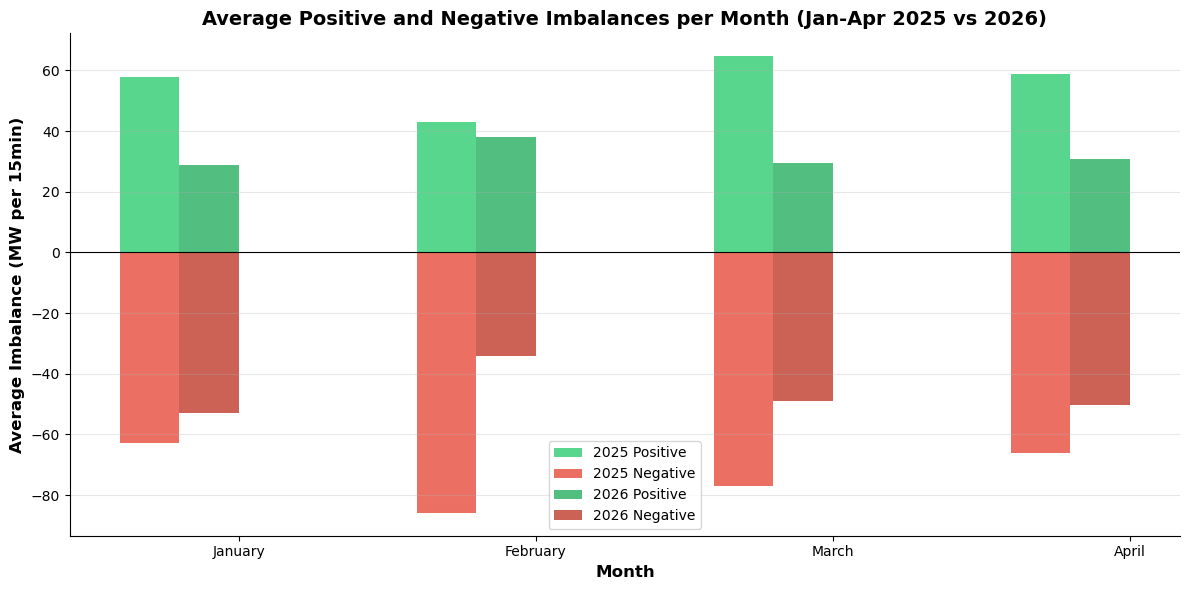


Monthly Average Imbalance Summary (MW per 15min):

2025:
       Positive Imbalance  Negative Imbalance
Month                                        
1               57.854492          -62.808095
2               43.035961          -85.847646
3               64.724227          -77.017794
4               58.891386          -65.975803

2026:
       Positive Imbalance  Negative Imbalance
Month                                        
1               28.964920          -53.011942
2               38.013874          -34.078387
3               29.460271          -49.054245
4               30.932032          -50.292614


In [112]:
import matplotlib.pyplot as plt

# Add month column to both dataframes
df_2025['Month'] = df_2025['Date Time'].dt.month
df_2026['Month'] = df_2026['Date Time'].dt.month

# Filter for months 1-4 (Jan-Apr)
df_2025_filtered = df_2025[df_2025['Month'].isin([1, 2, 3, 4])].copy()
df_2026_filtered = df_2026[df_2026['Month'].isin([1, 2, 3, 4])].copy()

# Create binary columns for positive and negative imbalances
df_2025_filtered['Positive Imbalance'] = df_2025_filtered['Total System Imbalance (Positiv = long / Negativ = short)'].clip(lower=0)
df_2025_filtered['Negative Imbalance'] = df_2025_filtered['Total System Imbalance (Positiv = long / Negativ = short)'].clip(upper=0)

df_2026_filtered['Positive Imbalance'] = df_2026_filtered['Total System Imbalance'].clip(lower=0)
df_2026_filtered['Negative Imbalance'] = df_2026_filtered['Total System Imbalance'].clip(upper=0)

# Group by month and calculate mean (average)
monthly_stats_2025 = df_2025_filtered.groupby('Month')[['Positive Imbalance', 'Negative Imbalance']].mean()
monthly_stats_2026 = df_2026_filtered.groupby('Month')[['Positive Imbalance', 'Negative Imbalance']].mean()

# Month names
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April'}

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

months = [1, 2, 3, 4]
x = np.arange(len(months))
width = 0.2

# Prepare data
pos_2025 = [monthly_stats_2025.loc[m, 'Positive Imbalance'] if m in monthly_stats_2025.index else 0 for m in months]
neg_2025 = [monthly_stats_2025.loc[m, 'Negative Imbalance'] if m in monthly_stats_2025.index else 0 for m in months]

pos_2026 = [monthly_stats_2026.loc[m, 'Positive Imbalance'] if m in monthly_stats_2026.index else 0 for m in months]
neg_2026 = [monthly_stats_2026.loc[m, 'Negative Imbalance'] if m in monthly_stats_2026.index else 0 for m in months]

# Create bars: negative below 0, positive above 0
ax.bar(x - width*1.5, pos_2025, width, label='2025 Positive', color='#2ecc71', alpha=0.8)
ax.bar(x - width*1.5, neg_2025, width, label='2025 Negative', color='#e74c3c', alpha=0.8)

ax.bar(x - width*0.5, pos_2026, width, label='2026 Positive', color='#27ae60', alpha=0.8)
ax.bar(x - width*0.5, neg_2026, width, label='2026 Negative', color='#c0392b', alpha=0.8)

# Customize plot
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Imbalance (MW per 15min)', fontsize=12, fontweight='bold')
ax.set_title('Average Positive and Negative Imbalances per Month (Jan-Apr 2025 vs 2026)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([month_names[m] for m in months])
ax.legend(loc='best')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print("\nMonthly Average Imbalance Summary (MW per 15min):")
print("\n2025:")
print(monthly_stats_2025)
print("\n2026:")
print(monthly_stats_2026)

## Imbalance Analysis by Day Groups (Jan-Apr 2025 vs 2026)


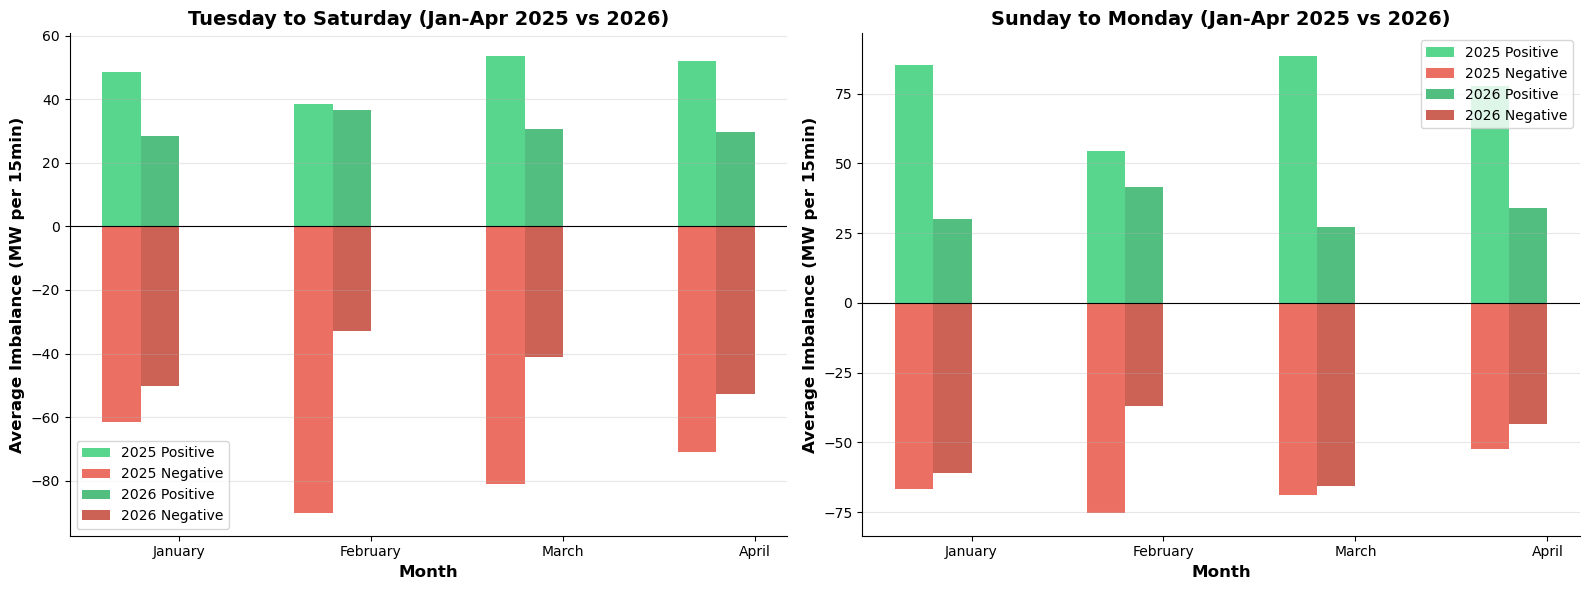


=== TUESDAY TO SATURDAY ===

2025:
       Positive Imbalance  Negative Imbalance
Month                                        
1               48.389061          -61.401510
2               38.551203          -90.077399
3               53.507483          -80.937333
4               52.120333          -70.980699

2026:
       Positive Imbalance  Negative Imbalance
Month                                        
1               28.537754          -50.228903
2               36.575091          -32.955132
3               30.495453          -41.104712
4               29.817804          -52.822414

=== SUNDAY TO MONDAY ===

2025:
       Positive Imbalance  Negative Imbalance
Month                                        
1               85.067606          -66.852027
2               54.247857          -75.273265
3               88.377947          -68.752322
4               77.511781          -52.212339

2026:
       Positive Imbalance  Negative Imbalance
Month                                      

In [113]:
# Add day of week column (0=Monday, 1=Tuesday, ..., 6=Sunday)
df_2025['DayOfWeek'] = df_2025['Date Time'].dt.dayofweek
df_2026['DayOfWeek'] = df_2026['Date Time'].dt.dayofweek

# Filter for months 1-4 and by day groups
# Tuesday to Saturday = [1, 2, 3, 4, 5]
# Sunday to Monday = [6, 0]
df_2025_tue_sat = df_2025[df_2025['Month'].isin([1, 2, 3, 4]) & df_2025['DayOfWeek'].isin([1, 2, 3, 4, 5])].copy()
df_2026_tue_sat = df_2026[df_2026['Month'].isin([1, 2, 3, 4]) & df_2026['DayOfWeek'].isin([1, 2, 3, 4, 5])].copy()

df_2025_sun_mon = df_2025[df_2025['Month'].isin([1, 2, 3, 4]) & df_2025['DayOfWeek'].isin([6, 0])].copy()
df_2026_sun_mon = df_2026[df_2026['Month'].isin([1, 2, 3, 4]) & df_2026['DayOfWeek'].isin([6, 0])].copy()

# Create imbalance columns for Tuesday-Saturday
df_2025_tue_sat['Positive Imbalance'] = df_2025_tue_sat['Total System Imbalance (Positiv = long / Negativ = short)'].clip(lower=0)
df_2025_tue_sat['Negative Imbalance'] = df_2025_tue_sat['Total System Imbalance (Positiv = long / Negativ = short)'].clip(upper=0)

df_2026_tue_sat['Positive Imbalance'] = df_2026_tue_sat['Total System Imbalance'].clip(lower=0)
df_2026_tue_sat['Negative Imbalance'] = df_2026_tue_sat['Total System Imbalance'].clip(upper=0)

# Create imbalance columns for Sunday-Monday
df_2025_sun_mon['Positive Imbalance'] = df_2025_sun_mon['Total System Imbalance (Positiv = long / Negativ = short)'].clip(lower=0)
df_2025_sun_mon['Negative Imbalance'] = df_2025_sun_mon['Total System Imbalance (Positiv = long / Negativ = short)'].clip(upper=0)

df_2026_sun_mon['Positive Imbalance'] = df_2026_sun_mon['Total System Imbalance'].clip(lower=0)
df_2026_sun_mon['Negative Imbalance'] = df_2026_sun_mon['Total System Imbalance'].clip(upper=0)

# Group by month for Tuesday-Saturday
monthly_stats_2025_tue_sat = df_2025_tue_sat.groupby('Month')[['Positive Imbalance', 'Negative Imbalance']].mean()
monthly_stats_2026_tue_sat = df_2026_tue_sat.groupby('Month')[['Positive Imbalance', 'Negative Imbalance']].mean()

# Group by month for Sunday-Monday
monthly_stats_2025_sun_mon = df_2025_sun_mon.groupby('Month')[['Positive Imbalance', 'Negative Imbalance']].mean()
monthly_stats_2026_sun_mon = df_2026_sun_mon.groupby('Month')[['Positive Imbalance', 'Negative Imbalance']].mean()

# Create plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

months = [1, 2, 3, 4]
x = np.arange(len(months))
width = 0.2

# ===== TUESDAY TO SATURDAY =====
pos_2025_tue_sat = [monthly_stats_2025_tue_sat.loc[m, 'Positive Imbalance'] if m in monthly_stats_2025_tue_sat.index else 0 for m in months]
neg_2025_tue_sat = [monthly_stats_2025_tue_sat.loc[m, 'Negative Imbalance'] if m in monthly_stats_2025_tue_sat.index else 0 for m in months]

pos_2026_tue_sat = [monthly_stats_2026_tue_sat.loc[m, 'Positive Imbalance'] if m in monthly_stats_2026_tue_sat.index else 0 for m in months]
neg_2026_tue_sat = [monthly_stats_2026_tue_sat.loc[m, 'Negative Imbalance'] if m in monthly_stats_2026_tue_sat.index else 0 for m in months]

ax1.bar(x - width*1.5, pos_2025_tue_sat, width, label='2025 Positive', color='#2ecc71', alpha=0.8)
ax1.bar(x - width*1.5, neg_2025_tue_sat, width, label='2025 Negative', color='#e74c3c', alpha=0.8)

ax1.bar(x - width*0.5, pos_2026_tue_sat, width, label='2026 Positive', color='#27ae60', alpha=0.8)
ax1.bar(x - width*0.5, neg_2026_tue_sat, width, label='2026 Negative', color='#c0392b', alpha=0.8)

ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Imbalance (MW per 15min)', fontsize=12, fontweight='bold')
ax1.set_title('Tuesday to Saturday (Jan-Apr 2025 vs 2026)', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([month_names[m] for m in months])
ax1.legend(loc='best')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0, color='black', linewidth=0.8)

# ===== SUNDAY TO MONDAY =====
pos_2025_sun_mon = [monthly_stats_2025_sun_mon.loc[m, 'Positive Imbalance'] if m in monthly_stats_2025_sun_mon.index else 0 for m in months]
neg_2025_sun_mon = [monthly_stats_2025_sun_mon.loc[m, 'Negative Imbalance'] if m in monthly_stats_2025_sun_mon.index else 0 for m in months]

pos_2026_sun_mon = [monthly_stats_2026_sun_mon.loc[m, 'Positive Imbalance'] if m in monthly_stats_2026_sun_mon.index else 0 for m in months]
neg_2026_sun_mon = [monthly_stats_2026_sun_mon.loc[m, 'Negative Imbalance'] if m in monthly_stats_2026_sun_mon.index else 0 for m in months]

ax2.bar(x - width*1.5, pos_2025_sun_mon, width, label='2025 Positive', color='#2ecc71', alpha=0.8)
ax2.bar(x - width*1.5, neg_2025_sun_mon, width, label='2025 Negative', color='#e74c3c', alpha=0.8)

ax2.bar(x - width*0.5, pos_2026_sun_mon, width, label='2026 Positive', color='#27ae60', alpha=0.8)
ax2.bar(x - width*0.5, neg_2026_sun_mon, width, label='2026 Negative', color='#c0392b', alpha=0.8)

ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Imbalance (MW per 15min)', fontsize=12, fontweight='bold')
ax2.set_title('Sunday to Monday (Jan-Apr 2025 vs 2026)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([month_names[m] for m in months])
ax2.legend(loc='best')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print("\n=== TUESDAY TO SATURDAY ===")
print("\n2025:")
print(monthly_stats_2025_tue_sat)
print("\n2026:")
print(monthly_stats_2026_tue_sat)

print("\n=== SUNDAY TO MONDAY ===")
print("\n2025:")
print(monthly_stats_2025_sun_mon)
print("\n2026:")
print(monthly_stats_2026_sun_mon)


## Statistical Test: Imbalance Reduction (2025 vs 2026)


In [114]:
from scipy import stats

# ===== OVERALL IMBALANCE (Jan-Apr) =====
# Extract absolute imbalances (magnitude regardless of sign)
imbalance_2025_all = df_2025_filtered['Total System Imbalance (Positiv = long / Negativ = short)'].abs()
imbalance_2026_all = df_2026_filtered['Total System Imbalance'].abs()

# Perform Mann-Whitney U test (non-parametric alternative to t-test)
statistic_all, pvalue_all = stats.mannwhitneyu(imbalance_2025_all, imbalance_2026_all, alternative='two-sided')

print("="*70)
print("OVERALL IMBALANCE TEST (Jan-Apr 2025 vs 2026)")
print("="*70)
print(f"2025 - Mean absolute imbalance: {imbalance_2025_all.mean():.4f} MW")
print(f"2026 - Mean absolute imbalance: {imbalance_2026_all.mean():.4f} MW")
print(f"Reduction: {imbalance_2025_all.mean() - imbalance_2026_all.mean():.4f} MW ({(1 - imbalance_2026_all.mean()/imbalance_2025_all.mean())*100:.2f}%)")
print(f"\nMann-Whitney U Test:")
print(f"  p-value: {pvalue_all:.6f}")
if pvalue_all < 0.05:
    print(f"  Result: SIGNIFICANT reduction (p < 0.05)")
else:
    print(f"  Result: NO significant reduction (p >= 0.05)")

# ===== POSITIVE IMBALANCE ONLY =====
pos_imb_2025_all = df_2025_filtered[df_2025_filtered['Positive Imbalance'] > 0]['Positive Imbalance']
pos_imb_2026_all = df_2026_filtered[df_2026_filtered['Positive Imbalance'] > 0]['Positive Imbalance']

statistic_pos, pvalue_pos = stats.mannwhitneyu(pos_imb_2025_all, pos_imb_2026_all, alternative='two-sided')

print("\n" + "="*70)
print("POSITIVE IMBALANCE TEST (Jan-Apr 2025 vs 2026)")
print("="*70)
print(f"2025 - Mean positive imbalance: {pos_imb_2025_all.mean():.4f} MW")
print(f"2026 - Mean positive imbalance: {pos_imb_2026_all.mean():.4f} MW")
print(f"Reduction: {pos_imb_2025_all.mean() - pos_imb_2026_all.mean():.4f} MW ({(1 - pos_imb_2026_all.mean()/pos_imb_2025_all.mean())*100:.2f}%)")
print(f"\nMann-Whitney U Test:")
print(f"  p-value: {pvalue_pos:.6f}")
if pvalue_pos < 0.05:
    print(f"  Result: SIGNIFICANT reduction (p < 0.05)")
else:
    print(f"  Result: NO significant reduction (p >= 0.05)")

# ===== NEGATIVE IMBALANCE (absolute value) =====
neg_imb_2025_all = df_2025_filtered[df_2025_filtered['Negative Imbalance'] < 0]['Negative Imbalance'].abs()
neg_imb_2026_all = df_2026_filtered[df_2026_filtered['Negative Imbalance'] < 0]['Negative Imbalance'].abs()

statistic_neg, pvalue_neg = stats.mannwhitneyu(neg_imb_2025_all, neg_imb_2026_all, alternative='two-sided')

print("\n" + "="*70)
print("NEGATIVE IMBALANCE TEST (Jan-Apr 2025 vs 2026)")
print("="*70)
print(f"2025 - Mean negative imbalance (abs): {neg_imb_2025_all.mean():.4f} MW")
print(f"2026 - Mean negative imbalance (abs): {neg_imb_2026_all.mean():.4f} MW")
print(f"Reduction: {neg_imb_2025_all.mean() - neg_imb_2026_all.mean():.4f} MW ({(1 - neg_imb_2026_all.mean()/neg_imb_2025_all.mean())*100:.2f}%)")
print(f"\nMann-Whitney U Test:")
print(f"  p-value: {pvalue_neg:.6f}")
if pvalue_neg < 0.05:
    print(f"  Result: SIGNIFICANT reduction (p < 0.05)")
else:
    print(f"  Result: NO significant reduction (p >= 0.05)")

# ===== BY DAY GROUP: TUESDAY-SATURDAY =====
print("\n" + "="*70)
print("TUESDAY TO SATURDAY - OVERALL IMBALANCE TEST")
print("="*70)
imb_2025_tue_sat = df_2025_tue_sat['Total System Imbalance (Positiv = long / Negativ = short)'].abs()
imb_2026_tue_sat = df_2026_tue_sat['Total System Imbalance'].abs()

statistic_tue_sat, pvalue_tue_sat = stats.mannwhitneyu(imb_2025_tue_sat, imb_2026_tue_sat, alternative='two-sided')
print(f"2025 - Mean absolute imbalance: {imb_2025_tue_sat.mean():.4f} MW")
print(f"2026 - Mean absolute imbalance: {imb_2026_tue_sat.mean():.4f} MW")
print(f"Reduction: {imb_2025_tue_sat.mean() - imb_2026_tue_sat.mean():.4f} MW ({(1 - imb_2026_tue_sat.mean()/imb_2025_tue_sat.mean())*100:.2f}%)")
print(f"p-value: {pvalue_tue_sat:.6f}")
if pvalue_tue_sat < 0.05:
    print(f"Result: SIGNIFICANT reduction (p < 0.05)")
else:
    print(f"Result: NO significant reduction (p >= 0.05)")

# ===== BY DAY GROUP: SUNDAY-MONDAY =====
print("\n" + "="*70)
print("SUNDAY TO MONDAY - OVERALL IMBALANCE TEST")
print("="*70)
imb_2025_sun_mon = df_2025_sun_mon['Total System Imbalance (Positiv = long / Negativ = short)'].abs()
imb_2026_sun_mon = df_2026_sun_mon['Total System Imbalance'].abs()

statistic_sun_mon, pvalue_sun_mon = stats.mannwhitneyu(imb_2025_sun_mon, imb_2026_sun_mon, alternative='two-sided')
print(f"2025 - Mean absolute imbalance: {imb_2025_sun_mon.mean():.4f} MW")
print(f"2026 - Mean absolute imbalance: {imb_2026_sun_mon.mean():.4f} MW")
print(f"Reduction: {imb_2025_sun_mon.mean() - imb_2026_sun_mon.mean():.4f} MW ({(1 - imb_2026_sun_mon.mean()/imb_2025_sun_mon.mean())*100:.2f}%)")
print(f"p-value: {pvalue_sun_mon:.6f}")
if pvalue_sun_mon < 0.05:
    print(f"Result: SIGNIFICANT reduction (p < 0.05)")
else:
    print(f"Result: NO significant reduction (p >= 0.05)")

print("\n" + "="*70)
print("SUMMARY: Significance level: α = 0.05")
print("="*70)


OVERALL IMBALANCE TEST (Jan-Apr 2025 vs 2026)
2025 - Mean absolute imbalance: 129.0731 MW
2026 - Mean absolute imbalance: 78.5870 MW
Reduction: 50.4861 MW (39.11%)

Mann-Whitney U Test:
  p-value: 0.000000
  Result: SIGNIFICANT reduction (p < 0.05)

POSITIVE IMBALANCE TEST (Jan-Apr 2025 vs 2026)
2025 - Mean positive imbalance: 125.4970 MW
2026 - Mean positive imbalance: 71.8817 MW
Reduction: 53.6153 MW (42.72%)

Mann-Whitney U Test:
  p-value: 0.000000
  Result: SIGNIFICANT reduction (p < 0.05)

NEGATIVE IMBALANCE TEST (Jan-Apr 2025 vs 2026)
2025 - Mean negative imbalance (abs): 131.9947 MW
2026 - Mean negative imbalance (abs): 83.8759 MW
Reduction: 48.1188 MW (36.46%)

Mann-Whitney U Test:
  p-value: 0.000000
  Result: SIGNIFICANT reduction (p < 0.05)

TUESDAY TO SATURDAY - OVERALL IMBALANCE TEST
2025 - Mean absolute imbalance: 123.5967 MW
2026 - Mean absolute imbalance: 75.8563 MW
Reduction: 47.7404 MW (38.63%)
p-value: 0.000000
Result: SIGNIFICANT reduction (p < 0.05)

SUNDAY TO MON

## Monthly Average Price Analysis (Jan-Apr 2025 vs 2026)


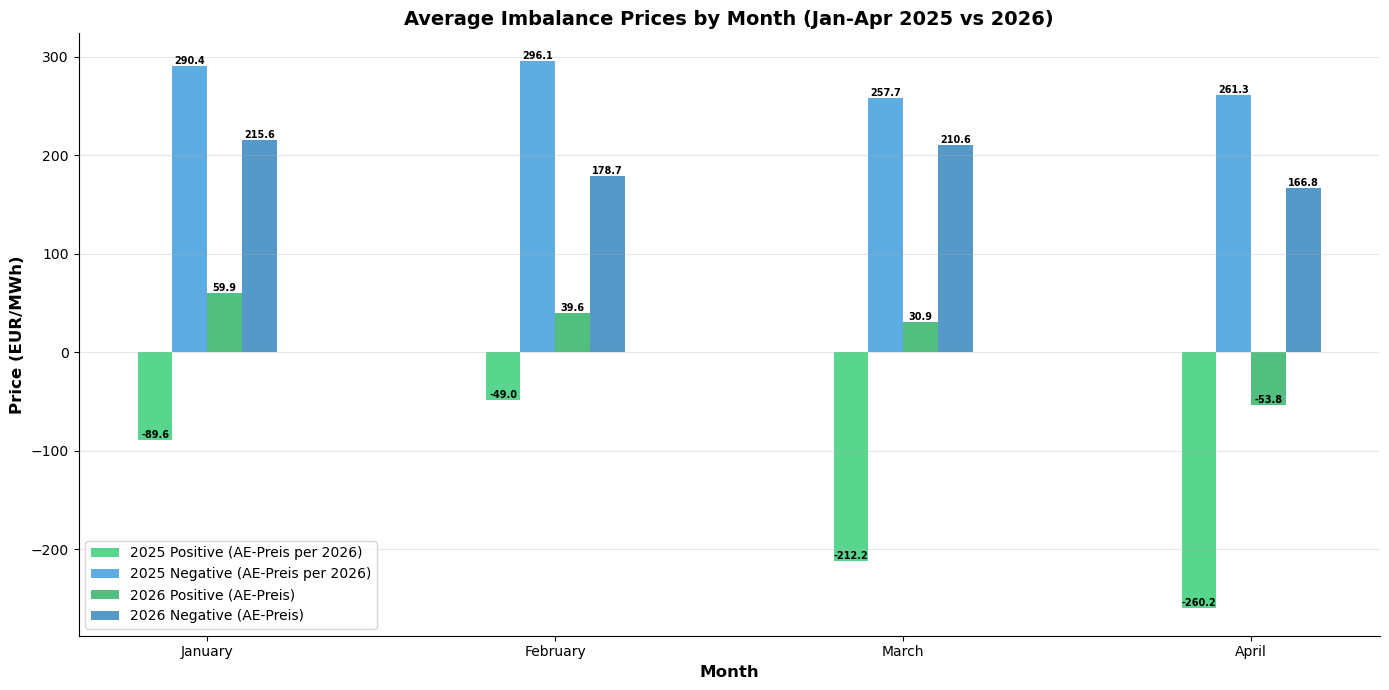

MONTHLY AVERAGE IMBALANCE PRICES (Jan-Apr 2025 vs 2026)

POSITIVE IMBALANCE PRICES (EUR/MWh):
----------------------------------------------------------------------------------------------------
Month        2025 (per 2026)      2026 (AE)            Change               % Change            
----------------------------------------------------------------------------------------------------
January                   -89.64               59.91              149.55              -166.8%
February                  -48.95               39.60               88.56              -180.9%
March                    -212.15               30.87              243.02              -114.5%
April                    -260.23              -53.79              206.44               -79.3%
----------------------------------------------------------------------------------------------------
Average                  -152.74               19.15              171.89              -112.5%

NEGATIVE IMBALANCE PRICES (EUR/MWh)

In [115]:
# Calculate monthly average prices by imbalance type
# Use AE-Preis per 2026 for 2025 data (for both positive and negative)
df_2025_filtered['Imbalance Sign'] = df_2025_filtered['Total System Imbalance (Positiv = long / Negativ = short)'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
df_2026_filtered['Imbalance Sign'] = df_2026_filtered['Total System Imbalance'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

# Calculate monthly prices for 2025 using AE-Preis per 2026
monthly_price_2025_pos = df_2025_filtered[df_2025_filtered['Imbalance Sign'] == 'Positive'].groupby('Month')['AE-Preis per 2026'].mean() * 10
monthly_price_2025_neg = df_2025_filtered[df_2025_filtered['Imbalance Sign'] == 'Negative'].groupby('Month')['AE-Preis per 2026'].mean() * 10

# Calculate monthly prices for 2026
monthly_price_2026_pos = df_2026_filtered[df_2026_filtered['Imbalance Sign'] == 'Positive'].groupby('Month')['AE-Preis'].mean() * 10
monthly_price_2026_neg = df_2026_filtered[df_2026_filtered['Imbalance Sign'] == 'Negative'].groupby('Month')['AE-Preis'].mean() * 10

# Create single plot with 4 bars per month (positive and negative for each year)
fig, ax = plt.subplots(figsize=(14, 7))

months_range = [1, 2, 3, 4]
x = np.arange(len(months_range))
width = 0.1

# Prepare data
pos_2025_prices = [monthly_price_2025_pos.get(m, 0) for m in months_range]
neg_2025_prices = [monthly_price_2025_neg.get(m, 0) for m in months_range]
pos_2026_prices = [monthly_price_2026_pos.get(m, 0) for m in months_range]
neg_2026_prices = [monthly_price_2026_neg.get(m, 0) for m in months_range]

# Create bars: 4 bars per month, fitting in 2 spaces
bars1 = ax.bar(x - width*1.5, pos_2025_prices, width, label='2025 Positive (AE-Preis per 2026)', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x - width*0.5, neg_2025_prices, width, label='2025 Negative (AE-Preis per 2026)', color='#3498db', alpha=0.8)
bars3 = ax.bar(x + width*0.5, pos_2026_prices, width, label='2026 Positive (AE-Preis)', color='#27ae60', alpha=0.8)
bars4 = ax.bar(x + width*1.5, neg_2026_prices, width, label='2026 Negative (AE-Preis)', color='#2980b9', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (EUR/MWh)', fontsize=12, fontweight='bold')
ax.set_title('Average Imbalance Prices by Month (Jan-Apr 2025 vs 2026)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([month_names[m] for m in months_range])
ax.legend(loc='best', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed summary
print("="*100)
print("MONTHLY AVERAGE IMBALANCE PRICES (Jan-Apr 2025 vs 2026)")
print("="*100)

print("\nPOSITIVE IMBALANCE PRICES (EUR/MWh):")
print("-" * 100)
print(f"{'Month':<12} {'2025 (per 2026)':<20} {'2026 (AE)':<20} {'Change':<20} {'% Change':<20}")
print("-" * 100)

for month_num, month_name in zip(months_range, [month_names[m] for m in months_range]):
    price_2025 = monthly_price_2025_pos.get(month_num, 0)
    price_2026 = monthly_price_2026_pos.get(month_num, 0)
    change = price_2026 - price_2025
    pct_change = (change / price_2025 * 100) if price_2025 != 0 else 0
    print(f"{month_name:<12} {price_2025:>19.2f} {price_2026:>19.2f} {change:>19.2f} {pct_change:>19.1f}%")

avg_pos_2025 = monthly_price_2025_pos.mean()
avg_pos_2026 = monthly_price_2026_pos.mean()
avg_change_pos = avg_pos_2026 - avg_pos_2025
avg_pct_change_pos = (avg_change_pos / avg_pos_2025 * 100) if avg_pos_2025 != 0 else 0
print("-" * 100)
print(f"{'Average':<12} {avg_pos_2025:>19.2f} {avg_pos_2026:>19.2f} {avg_change_pos:>19.2f} {avg_pct_change_pos:>19.1f}%")

print("\nNEGATIVE IMBALANCE PRICES (EUR/MWh):")
print("-" * 100)
print(f"{'Month':<12} {'2025 (per 2026)':<20} {'2026 (AE)':<20} {'Change':<20} {'% Change':<20}")
print("-" * 100)

for month_num, month_name in zip(months_range, [month_names[m] for m in months_range]):
    price_2025 = monthly_price_2025_neg.get(month_num, 0)
    price_2026 = monthly_price_2026_neg.get(month_num, 0)
    change = price_2026 - price_2025
    pct_change = (change / price_2025 * 100) if price_2025 != 0 else 0
    print(f"{month_name:<12} {price_2025:>19.2f} {price_2026:>19.2f} {change:>19.2f} {pct_change:>19.1f}%")

avg_neg_2025 = monthly_price_2025_neg.mean()
avg_neg_2026 = monthly_price_2026_neg.mean()
avg_change_neg = avg_neg_2026 - avg_neg_2025
avg_pct_change_neg = (avg_change_neg / avg_neg_2025 * 100) if avg_neg_2025 != 0 else 0
print("-" * 100)
print(f"{'Average':<12} {avg_neg_2025:>19.2f} {avg_neg_2026:>19.2f} {avg_change_neg:>19.2f} {avg_pct_change_neg:>19.1f}%")

print("="*100)


## Monthly Average Price Analysis by Day Groups (Jan-Apr 2025 vs 2026)


TUESDAY TO SATURDAY - MONTHLY AVERAGE IMBALANCE PRICES (Jan-Apr 2025 vs 2026)


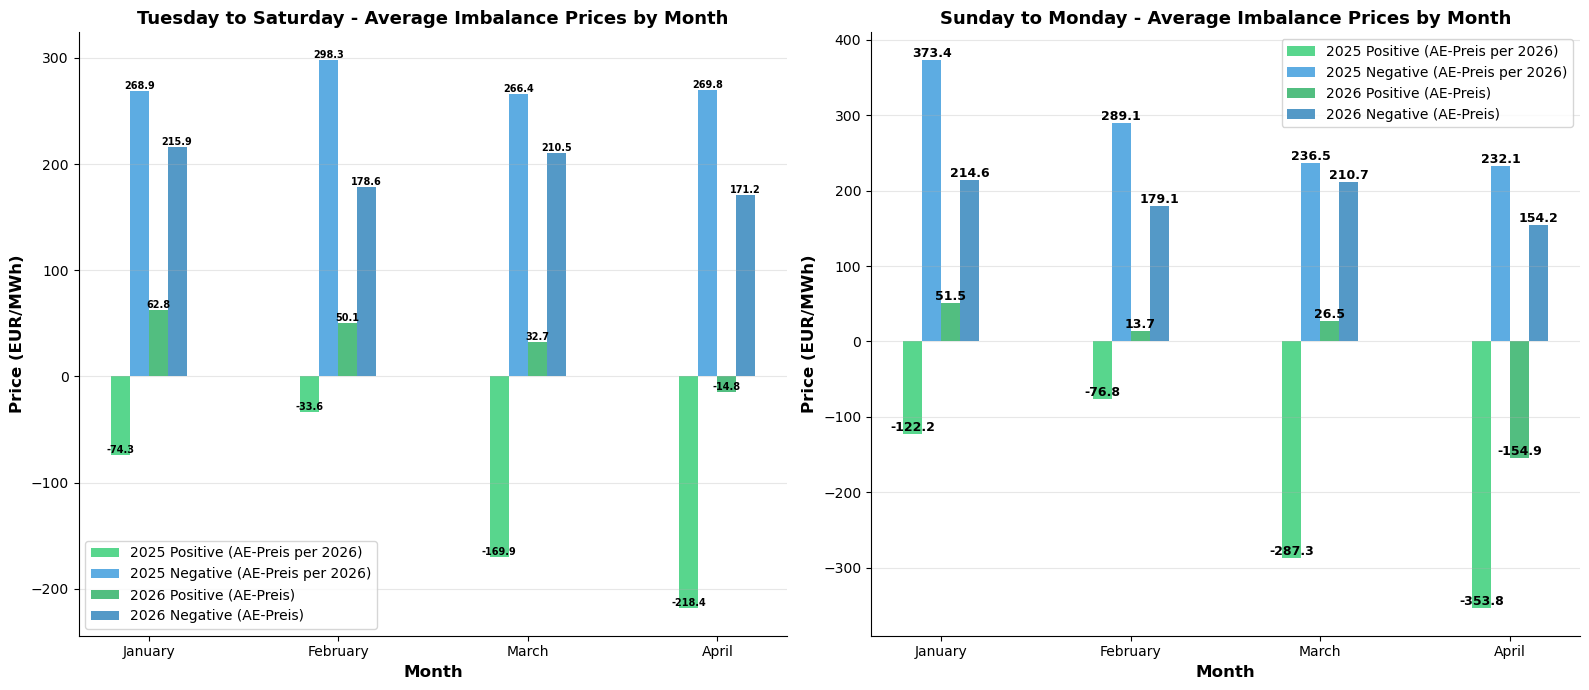


POSITIVE IMBALANCE PRICES (EUR/MWh):
----------------------------------------------------------------------------------------------------
Month        2025 (per 2026)      2026 (AE)            Change               % Change            
----------------------------------------------------------------------------------------------------
January                   -74.25               62.76              137.01              -184.5%
February                  -33.60               50.13               83.73              -249.2%
March                    -169.92               32.67              202.59              -119.2%
April                    -218.35              -14.75              203.60               -93.2%
----------------------------------------------------------------------------------------------------
Average                  -124.03               32.70              156.73              -126.4%

NEGATIVE IMBALANCE PRICES (EUR/MWh):
------------------------------------------------------

In [116]:
# ===== TUESDAY TO SATURDAY =====
print("="*100)
print("TUESDAY TO SATURDAY - MONTHLY AVERAGE IMBALANCE PRICES (Jan-Apr 2025 vs 2026)")
print("="*100)

# Add Imbalance Sign for day group dataframes
df_2025_tue_sat['Imbalance Sign'] = df_2025_tue_sat['Total System Imbalance (Positiv = long / Negativ = short)'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
df_2026_tue_sat['Imbalance Sign'] = df_2026_tue_sat['Total System Imbalance'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

# Add Imbalance Sign for Sunday-Monday (needed for later calculations)
df_2025_sun_mon['Imbalance Sign'] = df_2025_sun_mon['Total System Imbalance (Positiv = long / Negativ = short)'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
df_2026_sun_mon['Imbalance Sign'] = df_2026_sun_mon['Total System Imbalance'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

# Calculate monthly prices for Tuesday-Saturday
monthly_price_2025_pos_tue_sat = df_2025_tue_sat[df_2025_tue_sat['Imbalance Sign'] == 'Positive'].groupby('Month')['AE-Preis per 2026'].mean() * 10
monthly_price_2025_neg_tue_sat = df_2025_tue_sat[df_2025_tue_sat['Imbalance Sign'] == 'Negative'].groupby('Month')['AE-Preis per 2026'].mean() * 10

monthly_price_2026_pos_tue_sat = df_2026_tue_sat[df_2026_tue_sat['Imbalance Sign'] == 'Positive'].groupby('Month')['AE-Preis'].mean() * 10
monthly_price_2026_neg_tue_sat = df_2026_tue_sat[df_2026_tue_sat['Imbalance Sign'] == 'Negative'].groupby('Month')['AE-Preis'].mean() * 10

# Calculate monthly prices for Sunday-Monday
monthly_price_2025_pos_sun_mon = df_2025_sun_mon[df_2025_sun_mon['Imbalance Sign'] == 'Positive'].groupby('Month')['AE-Preis per 2026'].mean() * 10
monthly_price_2025_neg_sun_mon = df_2025_sun_mon[df_2025_sun_mon['Imbalance Sign'] == 'Negative'].groupby('Month')['AE-Preis per 2026'].mean() * 10

monthly_price_2026_pos_sun_mon = df_2026_sun_mon[df_2026_sun_mon['Imbalance Sign'] == 'Positive'].groupby('Month')['AE-Preis'].mean() * 10
monthly_price_2026_neg_sun_mon = df_2026_sun_mon[df_2026_sun_mon['Imbalance Sign'] == 'Negative'].groupby('Month')['AE-Preis'].mean() * 10

# Create plot for both day groups (side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

months_range = [1, 2, 3, 4]
x = np.arange(len(months_range))
width = 0.1

# ===== TUESDAY TO SATURDAY (LEFT) =====
pos_2025_prices_tue_sat = [monthly_price_2025_pos_tue_sat.get(m, 0) for m in months_range]
neg_2025_prices_tue_sat = [monthly_price_2025_neg_tue_sat.get(m, 0) for m in months_range]
pos_2026_prices_tue_sat = [monthly_price_2026_pos_tue_sat.get(m, 0) for m in months_range]
neg_2026_prices_tue_sat = [monthly_price_2026_neg_tue_sat.get(m, 0) for m in months_range]

bars1 = ax1.bar(x - width*1.5, pos_2025_prices_tue_sat, width, label='2025 Positive (AE-Preis per 2026)', color='#2ecc71', alpha=0.8)
bars2 = ax1.bar(x - width*0.5, neg_2025_prices_tue_sat, width, label='2025 Negative (AE-Preis per 2026)', color='#3498db', alpha=0.8)
bars3 = ax1.bar(x + width*0.5, pos_2026_prices_tue_sat, width, label='2026 Positive (AE-Preis)', color='#27ae60', alpha=0.8)
bars4 = ax1.bar(x + width*1.5, neg_2026_prices_tue_sat, width, label='2026 Negative (AE-Preis)', color='#2980b9', alpha=0.8)

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Price (EUR/MWh)', fontsize=12, fontweight='bold')
ax1.set_title('Tuesday to Saturday - Average Imbalance Prices by Month', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([month_names[m] for m in months_range])
ax1.legend(loc='best', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# ===== SUNDAY TO MONDAY (RIGHT) =====
pos_2025_prices_sun_mon = [monthly_price_2025_pos_sun_mon.get(m, 0) for m in months_range]
neg_2025_prices_sun_mon = [monthly_price_2025_neg_sun_mon.get(m, 0) for m in months_range]
pos_2026_prices_sun_mon = [monthly_price_2026_pos_sun_mon.get(m, 0) for m in months_range]
neg_2026_prices_sun_mon = [monthly_price_2026_neg_sun_mon.get(m, 0) for m in months_range]

bars5 = ax2.bar(x - width*1.5, pos_2025_prices_sun_mon, width, label='2025 Positive (AE-Preis per 2026)', color='#2ecc71', alpha=0.8)
bars6 = ax2.bar(x - width*0.5, neg_2025_prices_sun_mon, width, label='2025 Negative (AE-Preis per 2026)', color='#3498db', alpha=0.8)
bars7 = ax2.bar(x + width*0.5, pos_2026_prices_sun_mon, width, label='2026 Positive (AE-Preis)', color='#27ae60', alpha=0.8)
bars8 = ax2.bar(x + width*1.5, neg_2026_prices_sun_mon, width, label='2026 Negative (AE-Preis)', color='#2980b9', alpha=0.8)

for bars in [bars5, bars6, bars7, bars8]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Price (EUR/MWh)', fontsize=12, fontweight='bold')
ax2.set_title('Sunday to Monday - Average Imbalance Prices by Month', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([month_names[m] for m in months_range])
ax2.legend(loc='best', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPOSITIVE IMBALANCE PRICES (EUR/MWh):")
print("-" * 100)
print(f"{'Month':<12} {'2025 (per 2026)':<20} {'2026 (AE)':<20} {'Change':<20} {'% Change':<20}")
print("-" * 100)

for month_num, month_name in zip(months_range, [month_names[m] for m in months_range]):
    price_2025 = monthly_price_2025_pos_tue_sat.get(month_num, 0)
    price_2026 = monthly_price_2026_pos_tue_sat.get(month_num, 0)
    change = price_2026 - price_2025
    pct_change = (change / price_2025 * 100) if price_2025 != 0 else 0
    print(f"{month_name:<12} {price_2025:>19.2f} {price_2026:>19.2f} {change:>19.2f} {pct_change:>19.1f}%")

avg_pos_2025_tue_sat = monthly_price_2025_pos_tue_sat.mean()
avg_pos_2026_tue_sat = monthly_price_2026_pos_tue_sat.mean()
avg_change_pos_tue_sat = avg_pos_2026_tue_sat - avg_pos_2025_tue_sat
avg_pct_change_pos_tue_sat = (avg_change_pos_tue_sat / avg_pos_2025_tue_sat * 100) if avg_pos_2025_tue_sat != 0 else 0
print("-" * 100)
print(f"{'Average':<12} {avg_pos_2025_tue_sat:>19.2f} {avg_pos_2026_tue_sat:>19.2f} {avg_change_pos_tue_sat:>19.2f} {avg_pct_change_pos_tue_sat:>19.1f}%")

print("\nNEGATIVE IMBALANCE PRICES (EUR/MWh):")
print("-" * 100)
print(f"{'Month':<12} {'2025 (per 2026)':<20} {'2026 (AE)':<20} {'Change':<20} {'% Change':<20}")
print("-" * 100)

for month_num, month_name in zip(months_range, [month_names[m] for m in months_range]):
    price_2025 = monthly_price_2025_neg_tue_sat.get(month_num, 0)
    price_2026 = monthly_price_2026_neg_tue_sat.get(month_num, 0)
    change = price_2026 - price_2025
    pct_change = (change / price_2025 * 100) if price_2025 != 0 else 0
    print(f"{month_name:<12} {price_2025:>19.2f} {price_2026:>19.2f} {change:>19.2f} {pct_change:>19.1f}%")

avg_neg_2025_tue_sat = monthly_price_2025_neg_tue_sat.mean()
avg_neg_2026_tue_sat = monthly_price_2026_neg_tue_sat.mean()
avg_change_neg_tue_sat = avg_neg_2026_tue_sat - avg_neg_2025_tue_sat
avg_pct_change_neg_tue_sat = (avg_change_neg_tue_sat / avg_neg_2025_tue_sat * 100) if avg_neg_2025_tue_sat != 0 else 0
print("-" * 100)
print(f"{'Average':<12} {avg_neg_2025_tue_sat:>19.2f} {avg_neg_2026_tue_sat:>19.2f} {avg_change_neg_tue_sat:>19.2f} {avg_pct_change_neg_tue_sat:>19.1f}%")

print("="*100)

# ===== SUNDAY TO MONDAY =====
print("\n" + "="*100)
print("SUNDAY TO MONDAY - MONTHLY AVERAGE IMBALANCE PRICES (Jan-Apr 2025 vs 2026)")
print("="*100)

print("\nPOSITIVE IMBALANCE PRICES (EUR/MWh):")
print("-" * 100)
print(f"{'Month':<12} {'2025 (per 2026)':<20} {'2026 (AE)':<20} {'Change':<20} {'% Change':<20}")
print("-" * 100)

for month_num, month_name in zip(months_range, [month_names[m] for m in months_range]):
    price_2025 = monthly_price_2025_pos_sun_mon.get(month_num, 0)
    price_2026 = monthly_price_2026_pos_sun_mon.get(month_num, 0)
    change = price_2026 - price_2025
    pct_change = (change / price_2025 * 100) if price_2025 != 0 else 0
    print(f"{month_name:<12} {price_2025:>19.2f} {price_2026:>19.2f} {change:>19.2f} {pct_change:>19.1f}%")

avg_pos_2025_sun_mon = monthly_price_2025_pos_sun_mon.mean()
avg_pos_2026_sun_mon = monthly_price_2026_pos_sun_mon.mean()
avg_change_pos_sun_mon = avg_pos_2026_sun_mon - avg_pos_2025_sun_mon
avg_pct_change_pos_sun_mon = (avg_change_pos_sun_mon / avg_pos_2025_sun_mon * 100) if avg_pos_2025_sun_mon != 0 else 0
print("-" * 100)
print(f"{'Average':<12} {avg_pos_2025_sun_mon:>19.2f} {avg_pos_2026_sun_mon:>19.2f} {avg_change_pos_sun_mon:>19.2f} {avg_pct_change_pos_sun_mon:>19.1f}%")

print("\nNEGATIVE IMBALANCE PRICES (EUR/MWh):")
print("-" * 100)
print(f"{'Month':<12} {'2025 (per 2026)':<20} {'2026 (AE)':<20} {'Change':<20} {'% Change':<20}")
print("-" * 100)

for month_num, month_name in zip(months_range, [month_names[m] for m in months_range]):
    price_2025 = monthly_price_2025_neg_sun_mon.get(month_num, 0)
    price_2026 = monthly_price_2026_neg_sun_mon.get(month_num, 0)
    change = price_2026 - price_2025
    pct_change = (change / price_2025 * 100) if price_2025 != 0 else 0
    print(f"{month_name:<12} {price_2025:>19.2f} {price_2026:>19.2f} {change:>19.2f} {pct_change:>19.1f}%")

avg_neg_2025_sun_mon = monthly_price_2025_neg_sun_mon.mean()
avg_neg_2026_sun_mon = monthly_price_2026_neg_sun_mon.mean()
avg_change_neg_sun_mon = avg_neg_2026_sun_mon - avg_neg_2025_sun_mon
avg_pct_change_neg_sun_mon = (avg_change_neg_sun_mon / avg_neg_2025_sun_mon * 100) if avg_neg_2025_sun_mon != 0 else 0
print("-" * 100)
print(f"{'Average':<12} {avg_neg_2025_sun_mon:>19.2f} {avg_neg_2026_sun_mon:>19.2f} {avg_change_neg_sun_mon:>19.2f} {avg_pct_change_neg_sun_mon:>19.1f}%")

print("="*100)

## Imbalance persistence analysis

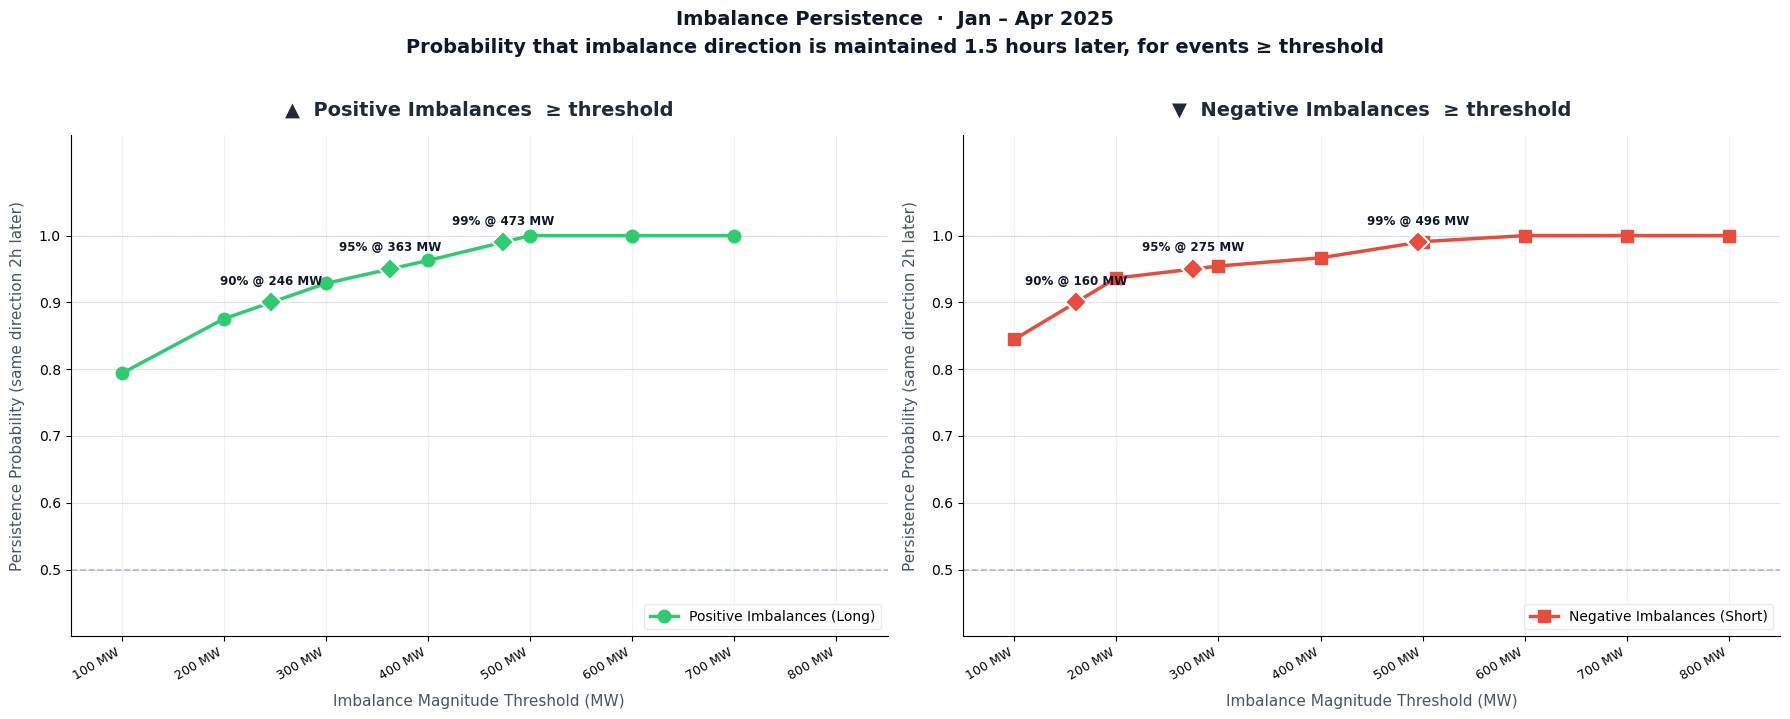

In [89]:
df_sorted = df_2025.sort_values('Date Time').reset_index(drop=True)
df_sorted['future_imbalance'] = df_sorted['Total System Imbalance (Positiv = long / Negativ = short)'].shift(-6)
df_sorted = df_sorted.dropna(subset=['future_imbalance'])
df_sorted = df_sorted[df_sorted['Month'].isin([1, 2, 3, 4])]

thresholds = list(range(100, 801, 100))

plt.rcParams.update({'font.family': 'sans-serif', 'axes.spines.top': False, 'axes.spines.right': False})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
fig.patch.set_facecolor('white')

for ax in [ax1, ax2]:
    ax.set_facecolor('white')

for direction, sign, ax, color, marker, label in [
    ('Positive', 1,  ax1, '#2ecc71', 'o', 'Positive Imbalances (Long)'),
    ('Negative', -1, ax2, '#e74c3c', 's', 'Negative Imbalances (Short)'),
]:
    sub = df_sorted[df_sorted['Total System Imbalance (Positiv = long / Negativ = short)'] * sign > 0].copy()
    sub['abs_imbalance'] = sub['Total System Imbalance (Positiv = long / Negativ = short)'].abs()

    probs, counts = [], []
    for thr in thresholds:
        mask = sub['abs_imbalance'] >= thr
        n = mask.sum()
        p = (sub.loc[mask, 'future_imbalance'] * sign > 0).mean() if n > 0 else np.nan
        probs.append(p)
        counts.append(n)

    probs = np.array(probs)
    counts = np.array(counts)
    valid = ~np.isnan(probs)
    xs = np.array(thresholds)[valid]
    ys = probs[valid]

    ax.plot(xs, ys, marker=marker, linewidth=2.5, markersize=9, color=color, label=label, zorder=3)

    ax.axhline(y=0.5, color='#94a3b8', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.axhline(y=1.0, color='#cbd5e1', linestyle=':', linewidth=1, alpha=0.5)

    for level, lname in [(0.90, '90%'), (0.95, '95%'), (0.99, '99%')]:
        cross_x = None
        for i in range(len(ys) - 1):
            if ys[i] < level <= ys[i+1]:
                cross_x = xs[i] + (level - ys[i]) / (ys[i+1] - ys[i]) * (xs[i+1] - xs[i])
                break
        if cross_x is not None:
            ax.plot(cross_x, level, marker='D', markersize=11,
                    color=color, zorder=5, markeredgecolor='white', markeredgewidth=1.5)
            ax.text(cross_x, level + 0.022, f'{lname} @ {cross_x:.0f} MW',
                    ha='center', va='bottom', fontsize=8.5,
                    color='#0f172a', fontweight='bold')

    ax.set_xlim([50, 850])
    ax.set_xticks(thresholds)
    ax.set_xticklabels([f'{t} MW' for t in thresholds], fontsize=9, rotation=30, ha='right')
    ax.set_ylim([0.4, 1.15])
    ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax.set_yticklabels([f'{v:.1f}' for v in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]], fontsize=10)
    ax.tick_params(axis='y', labelleft=True)
    ax.grid(axis='y', alpha=0.3, color='#94a3b8', linewidth=0.8)
    ax.grid(axis='x', alpha=0.15, color='#94a3b8', linewidth=0.8)

    icon = '▲' if direction == 'Positive' else '▼'
    ax.set_title(f'{icon}  {direction} Imbalances  ≥ threshold',
                 fontsize=14, fontweight='bold', pad=14, color='#1e293b')
    ax.set_xlabel('Imbalance Magnitude Threshold (MW)', fontsize=11, labelpad=8, color='#475569')
    ax.set_ylabel('Persistence Probability (same direction 2h later)', fontsize=11, labelpad=10, color='#475569')
    ax.legend(loc='lower right', fontsize=10, frameon=True, framealpha=0.9,
              edgecolor='#e2e8f0', facecolor='white')

fig.suptitle('Imbalance Persistence  ·  Jan – Apr 2025\nProbability that imbalance direction is maintained 1.5 hours later, for events ≥ threshold',
             fontsize=14, fontweight='bold', color='#0f172a', y=1.02, linespacing=1.6)

plt.tight_layout()
plt.show()

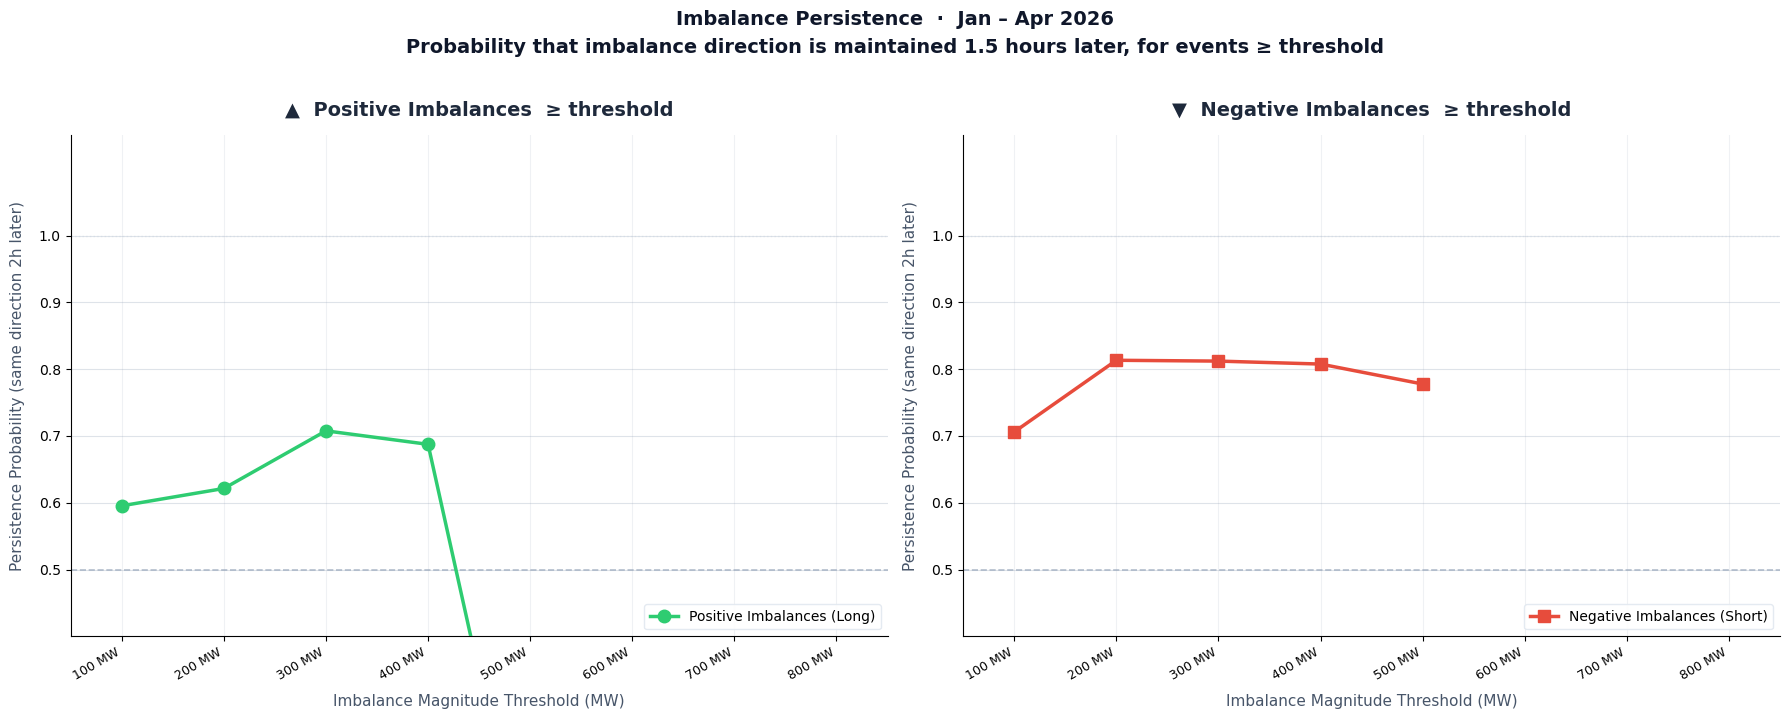

In [90]:
import numpy as np
import matplotlib.pyplot as plt

df_sorted = df_2026.sort_values('Date Time').reset_index(drop=True)
df_sorted['future_imbalance'] = df_sorted['Total System Imbalance'].shift(-6)
df_sorted = df_sorted.dropna(subset=['future_imbalance'])
df_sorted = df_sorted[df_sorted['Month'].isin([1, 2, 3, 4])]

thresholds = list(range(100, 801, 100))

plt.rcParams.update({'font.family': 'sans-serif', 'axes.spines.top': False, 'axes.spines.right': False})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
fig.patch.set_facecolor('white')

for ax in [ax1, ax2]:
    ax.set_facecolor('white')

for direction, sign, ax, color, marker, label in [
    ('Positive', 1,  ax1, '#2ecc71', 'o', 'Positive Imbalances (Long)'),
    ('Negative', -1, ax2, '#e74c3c', 's', 'Negative Imbalances (Short)'),
]:
    sub = df_sorted[df_sorted['Total System Imbalance'] * sign > 0].copy()
    sub['abs_imbalance'] = sub['Total System Imbalance'].abs()

    probs, counts = [], []
    for thr in thresholds:
        mask = sub['abs_imbalance'] >= thr
        n = mask.sum()
        p = (sub.loc[mask, 'future_imbalance'] * sign > 0).mean() if n > 0 else np.nan
        probs.append(p)
        counts.append(n)

    probs = np.array(probs)
    counts = np.array(counts)
    valid = ~np.isnan(probs)
    xs = np.array(thresholds)[valid]
    ys = probs[valid]

    ax.plot(xs, ys, marker=marker, linewidth=2.5, markersize=9, color=color, label=label, zorder=3)

    ax.axhline(y=0.5, color='#94a3b8', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.axhline(y=1.0, color='#cbd5e1', linestyle=':', linewidth=1, alpha=0.5)

    for level, lname in [(0.90, '90%'), (0.95, '95%'), (0.99, '99%')]:
        cross_x = None
        for i in range(len(ys) - 1):
            if ys[i] < level <= ys[i+1]:
                cross_x = xs[i] + (level - ys[i]) / (ys[i+1] - ys[i]) * (xs[i+1] - xs[i])
                break
        if cross_x is not None:
            ax.plot(cross_x, level, marker='D', markersize=11,
                    color=color, zorder=5, markeredgecolor='white', markeredgewidth=1.5)
            ax.text(cross_x, level + 0.022, f'{lname} @ {cross_x:.0f} MW',
                    ha='center', va='bottom', fontsize=8.5,
                    color='#0f172a', fontweight='bold')

    ax.set_xlim([50, 850])
    ax.set_xticks(thresholds)
    ax.set_xticklabels([f'{t} MW' for t in thresholds], fontsize=9, rotation=30, ha='right')
    ax.set_ylim([0.4, 1.15])
    ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax.set_yticklabels([f'{v:.1f}' for v in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]], fontsize=10)
    ax.tick_params(axis='y', labelleft=True)
    ax.grid(axis='y', alpha=0.3, color='#94a3b8', linewidth=0.8)
    ax.grid(axis='x', alpha=0.15, color='#94a3b8', linewidth=0.8)

    icon = '▲' if direction == 'Positive' else '▼'
    ax.set_title(f'{icon}  {direction} Imbalances  ≥ threshold',
                 fontsize=14, fontweight='bold', pad=14, color='#1e293b')
    ax.set_xlabel('Imbalance Magnitude Threshold (MW)', fontsize=11, labelpad=8, color='#475569')
    ax.set_ylabel('Persistence Probability (same direction 2h later)', fontsize=11, labelpad=10, color='#475569')
    ax.legend(loc='lower right', fontsize=10, frameon=True, framealpha=0.9,
              edgecolor='#e2e8f0', facecolor='white')

fig.suptitle('Imbalance Persistence  ·  Jan – Apr 2026\nProbability that imbalance direction is maintained 1.5 hours later, for events ≥ threshold',
             fontsize=14, fontweight='bold', color='#0f172a', y=1.02, linespacing=1.6)

plt.tight_layout()
plt.show()

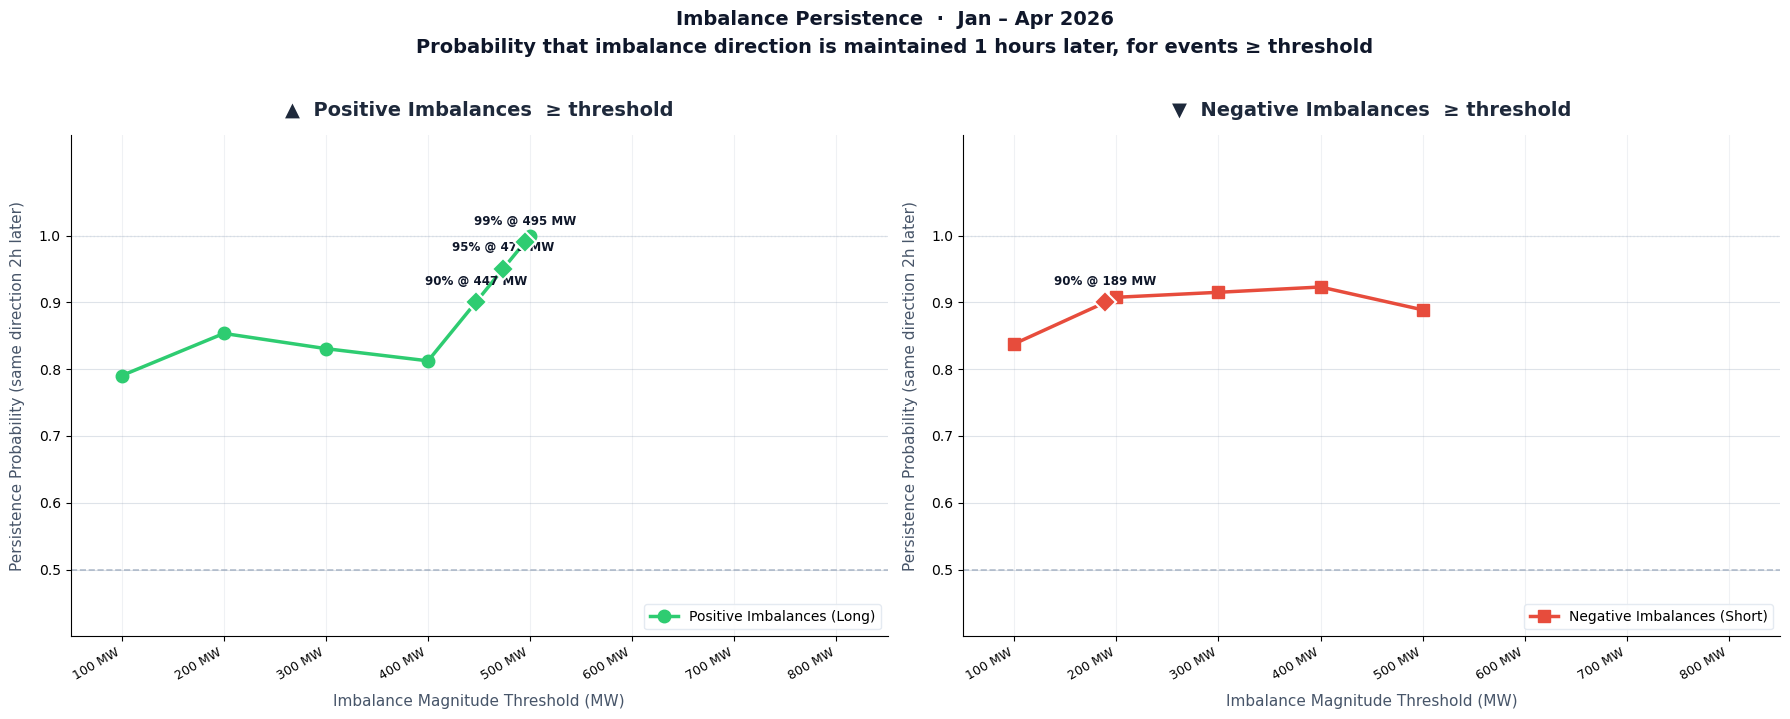

In [91]:
import numpy as np
import matplotlib.pyplot as plt

df_sorted = df_2026.sort_values('Date Time').reset_index(drop=True)
df_sorted['future_imbalance'] = df_sorted['Total System Imbalance'].shift(-4)
df_sorted = df_sorted.dropna(subset=['future_imbalance'])
df_sorted = df_sorted[df_sorted['Month'].isin([1, 2, 3, 4])]

thresholds = list(range(100, 801, 100))

plt.rcParams.update({'font.family': 'sans-serif', 'axes.spines.top': False, 'axes.spines.right': False})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
fig.patch.set_facecolor('white')

for ax in [ax1, ax2]:
    ax.set_facecolor('white')

for direction, sign, ax, color, marker, label in [
    ('Positive', 1,  ax1, '#2ecc71', 'o', 'Positive Imbalances (Long)'),
    ('Negative', -1, ax2, '#e74c3c', 's', 'Negative Imbalances (Short)'),
]:
    sub = df_sorted[df_sorted['Total System Imbalance'] * sign > 0].copy()
    sub['abs_imbalance'] = sub['Total System Imbalance'].abs()

    probs, counts = [], []
    for thr in thresholds:
        mask = sub['abs_imbalance'] >= thr
        n = mask.sum()
        p = (sub.loc[mask, 'future_imbalance'] * sign > 0).mean() if n > 0 else np.nan
        probs.append(p)
        counts.append(n)

    probs = np.array(probs)
    counts = np.array(counts)
    valid = ~np.isnan(probs)
    xs = np.array(thresholds)[valid]
    ys = probs[valid]

    ax.plot(xs, ys, marker=marker, linewidth=2.5, markersize=9, color=color, label=label, zorder=3)

    ax.axhline(y=0.5, color='#94a3b8', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.axhline(y=1.0, color='#cbd5e1', linestyle=':', linewidth=1, alpha=0.5)

    for level, lname in [(0.90, '90%'), (0.95, '95%'), (0.99, '99%')]:
        cross_x = None
        for i in range(len(ys) - 1):
            if ys[i] < level <= ys[i+1]:
                cross_x = xs[i] + (level - ys[i]) / (ys[i+1] - ys[i]) * (xs[i+1] - xs[i])
                break
        if cross_x is not None:
            ax.plot(cross_x, level, marker='D', markersize=11,
                    color=color, zorder=5, markeredgecolor='white', markeredgewidth=1.5)
            ax.text(cross_x, level + 0.022, f'{lname} @ {cross_x:.0f} MW',
                    ha='center', va='bottom', fontsize=8.5,
                    color='#0f172a', fontweight='bold')

    ax.set_xlim([50, 850])
    ax.set_xticks(thresholds)
    ax.set_xticklabels([f'{t} MW' for t in thresholds], fontsize=9, rotation=30, ha='right')
    ax.set_ylim([0.4, 1.15])
    ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax.set_yticklabels([f'{v:.1f}' for v in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]], fontsize=10)
    ax.tick_params(axis='y', labelleft=True)
    ax.grid(axis='y', alpha=0.3, color='#94a3b8', linewidth=0.8)
    ax.grid(axis='x', alpha=0.15, color='#94a3b8', linewidth=0.8)

    icon = '▲' if direction == 'Positive' else '▼'
    ax.set_title(f'{icon}  {direction} Imbalances  ≥ threshold',
                 fontsize=14, fontweight='bold', pad=14, color='#1e293b')
    ax.set_xlabel('Imbalance Magnitude Threshold (MW)', fontsize=11, labelpad=8, color='#475569')
    ax.set_ylabel('Persistence Probability (same direction 2h later)', fontsize=11, labelpad=10, color='#475569')
    ax.legend(loc='lower right', fontsize=10, frameon=True, framealpha=0.9,
              edgecolor='#e2e8f0', facecolor='white')

fig.suptitle('Imbalance Persistence  ·  Jan – Apr 2026\nProbability that imbalance direction is maintained 1 hours later, for events ≥ threshold',
             fontsize=14, fontweight='bold', color='#0f172a', y=1.02, linespacing=1.6)

plt.tight_layout()
plt.show()

## Intraday deals analysis, optimisation and back-testing

In [92]:
import pandas as pd
import numpy as np

trades = pd.read_excel("Trades_GE_jan_apr.xlsx")
trades['Date Time'] = pd.to_datetime(trades['Date Time'])

df_csv = pd.read_csv("control-area-balance-2026.csv", sep=';')
df_csv['Date Time [UTC]'] = pd.to_datetime(df_csv['Date Time [UTC]'], format='%d.%m.%Y %H:%M')

mask = df_csv['Date Time [UTC]'].dt.month.isin([1, 2, 3, 4])

df_hourly = (
    df_csv[mask]
    .groupby(df_csv.loc[mask, 'Date Time [UTC]'].dt.floor('h'))[['AE-Preis', 'Total System Imbalance']]
    .mean()
    .reset_index()
    .rename(columns={'Date Time [UTC]': 'hour', 'AE-Preis': 'Imbalance price'})
)

trades['hour_key'] = trades['Date Time'].dt.floor('h')
trades = trades.merge(df_hourly, left_on='hour_key', right_on='hour', how='left')
trades = trades.drop(columns=['hour', 'hour_key'])

trades['Imbalance price'] = trades['Imbalance price'] * 10

imbalance_neg = trades['Total System Imbalance'] < 0
imbalance_pos = trades['Total System Imbalance'] > 0
is_sell = trades['Buy/Sell'].str.lower() == 's'
is_buy  = trades['Buy/Sell'].str.lower() == 'b'

prev_imbalance = trades['Total System Imbalance'].shift(1)
trades['Threshold reached'] = (prev_imbalance < -189) | (prev_imbalance > 447)

trades['Opposite direction'] = (imbalance_neg & is_sell) | (imbalance_pos & is_buy)

condition = trades['Threshold reached'] & trades['Opposite direction']
trades['Cost Swissgrid'] = np.where(condition, trades['Net'] * trades['Imbalance price'], np.nan)

trades['PnL vs Swissgrid'] = (trades['Cost Swissgrid'] - trades['Intraday cost'])*-1

is_sell = trades['Buy/Sell'].str.lower() == 's'
is_buy  = trades['Buy/Sell'].str.lower() == 'b'

trades['EA price better'] = (
    (is_sell & (trades['Imbalance price'] > trades['Price'])) |
    (is_buy  & (trades['Imbalance price'] < trades['Price']))
)

condition = trades['EA price better'] & trades['Opposite direction']
trades['Cost Swissgrid with perfect forecast'] = np.where(condition, trades['Net'] * trades['Imbalance price'], np.nan)

trades['PnL vs Swissgrid with perfect forecast'] = (trades['Cost Swissgrid with perfect forecast'] - trades['Intraday cost'])*-1

print(f"Total PnL vs Swissgrid: {trades['PnL vs Swissgrid'].sum()}")
print(f"Total PnL vs Swissgrid with perfect forecast: {trades['PnL vs Swissgrid with perfect forecast'].sum()}")

trades.head()

Total PnL vs Swissgrid: 45768.34
Total PnL vs Swissgrid with perfect forecast: 316904.485


,Date Time,Buy,Buy price,Sell,Sell price,Net,Price,Buy/Sell,Intraday cost,Imbalance price,Total System Imbalance,Threshold reached,Opposite direction,Cost Swissgrid,PnL vs Swissgrid,EA price better,Cost Swissgrid with perfect forecast,PnL vs Swissgrid with perfect forecast
0,2026-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,170.750,-205.273220,False,False,NaN,NaN,False,NaN,NaN
1,2026-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,168.625,-151.052351,True,False,NaN,NaN,False,NaN,NaN
2,2026-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,146.500,-114.907925,False,False,NaN,NaN,False,NaN,NaN
3,2026-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,-191.725,157.370890,False,False,NaN,NaN,False,NaN,NaN
4,2026-01-01 05:00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,-107.425,147.487271,False,False,NaN,NaN,False,NaN,NaN


In [93]:
trades['PnL vs Swissgrid'].sum() 


np.float64(45768.34)

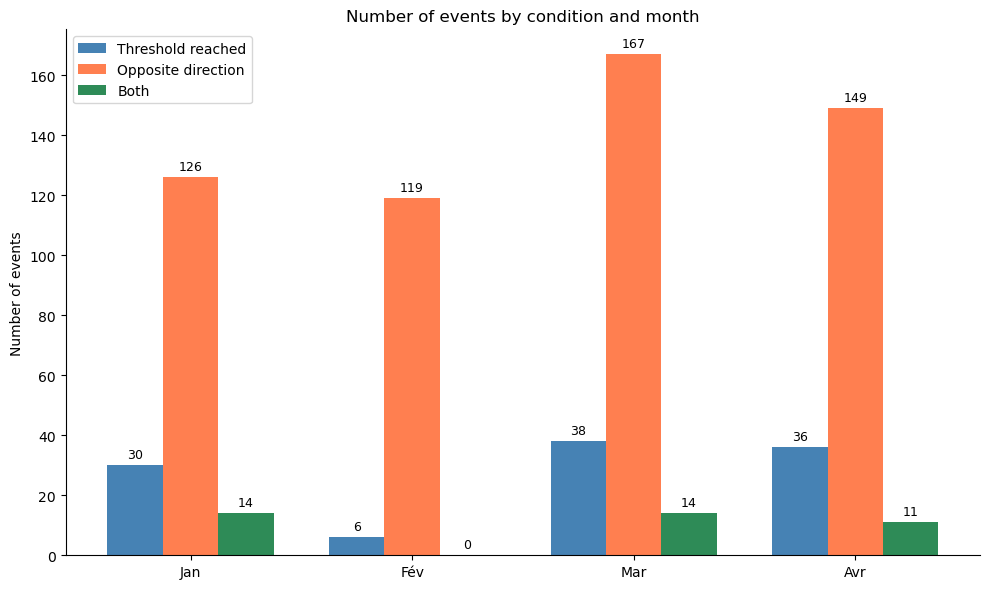

In [94]:
import matplotlib.pyplot as plt
import numpy as np

months = {1: 'Jan', 2: 'Fév', 3: 'Mar', 4: 'Avr'}

monthly = trades.groupby(trades['Date Time'].dt.month).apply(lambda g: pd.Series({
    'Threshold reached': g['Threshold reached'].sum(),
    'Opposite direction': g['Opposite direction'].sum(),
    'Both': (g['Threshold reached'] & g['Opposite direction']).sum()
})).rename(index=months)

x = np.arange(len(monthly))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width, monthly['Threshold reached'], width, label='Threshold reached', color='steelblue')
b2 = ax.bar(x,         monthly['Opposite direction'],  width, label='Opposite direction',  color='coral')
b3 = ax.bar(x + width, monthly['Both'],                width, label='Both',                color='seagreen')

ax.bar_label(b1, padding=3, fontsize=9)
ax.bar_label(b2, padding=3, fontsize=9)
ax.bar_label(b3, padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(monthly.index)
ax.set_title("Number of events by condition and month")
ax.set_ylabel("Number of events")
ax.legend()

plt.tight_layout()
plt.show()

In [95]:
from scipy.optimize import minimize
import pandas as pd
import numpy as np

# Reload the base data to avoid modifying the trades df
trades_opt = pd.read_excel("Trades_GE_jan_apr.xlsx")
trades_opt['Date Time'] = pd.to_datetime(trades_opt['Date Time'])

df_csv = pd.read_csv("control-area-balance-2026.csv", sep=';')
df_csv['Date Time [UTC]'] = pd.to_datetime(df_csv['Date Time [UTC]'], format='%d.%m.%Y %H:%M')

mask = df_csv['Date Time [UTC]'].dt.month.isin([1, 2, 3, 4])

df_hourly = (
    df_csv[mask]
    .groupby(df_csv.loc[mask, 'Date Time [UTC]'].dt.floor('h'))[['AE-Preis', 'Total System Imbalance']]
    .mean()
    .reset_index()
    .rename(columns={'Date Time [UTC]': 'hour', 'AE-Preis': 'Imbalance price'})
)

trades_opt['hour_key'] = trades_opt['Date Time'].dt.floor('h')
trades_opt = trades_opt.merge(df_hourly, left_on='hour_key', right_on='hour', how='left')
trades_opt = trades_opt.drop(columns=['hour', 'hour_key'])

trades_opt['Imbalance price'] = trades_opt['Imbalance price'] * 10

imbalance_neg = trades_opt['Total System Imbalance'] < 0
imbalance_pos = trades_opt['Total System Imbalance'] > 0
is_sell = trades_opt['Buy/Sell'].str.lower() == 's'
is_buy  = trades_opt['Buy/Sell'].str.lower() == 'b'

prev_imbalance = trades_opt['Total System Imbalance'].shift(1)

def calculate_pnl(thresholds):
    """Calculate negative PnL (for minimization) given threshold values"""
    threshold_low, threshold_high = thresholds
    
    trades_opt['Threshold reached'] = (prev_imbalance < threshold_low) | (prev_imbalance > threshold_high)
    trades_opt['Opposite direction'] = (imbalance_neg & is_sell) | (imbalance_pos & is_buy)
    
    condition = trades_opt['Threshold reached'] & trades_opt['Opposite direction']
    trades_opt['Cost Swissgrid'] = np.where(condition, trades_opt['Net'] * trades_opt['Imbalance price'], np.nan)
    
    trades_opt['PnL vs Swissgrid'] = (trades_opt['Cost Swissgrid'] - trades_opt['Intraday cost']) * -1
    
    total_pnl = trades_opt['PnL vs Swissgrid'].sum()
    return -total_pnl  # Return negative because we want to maximize

# Initial guess
initial_thresholds = [-189, 447]

# Optimize
result = minimize(
    calculate_pnl,
    initial_thresholds,
    method='Nelder-Mead',
    options={'maxiter': 5000, 'xatol': 1, 'fatol': 1}
)

optimal_threshold_low, optimal_threshold_high = result.x
optimal_pnl = -result.fun

print(f"Optimal threshold low: {optimal_threshold_low:.2f}")
print(f"Optimal threshold high: {optimal_threshold_high:.2f}")
print(f"Optimal PnL vs Swissgrid: {optimal_pnl:.2f}")
print(f"\nImprovement vs original (-189, 447):")
print(f"Original thresholds PnL: {trades['PnL vs Swissgrid'].sum():.2f}")
print(f"Improvement: {optimal_pnl - trades['PnL vs Swissgrid'].sum():.2f}")


Optimal threshold low: -179.55
Optimal threshold high: 469.35
Optimal PnL vs Swissgrid: 50455.35

Improvement vs original (-189, 447):
Original thresholds PnL: 45768.34
Improvement: 4687.01


In [96]:
import pandas as pd
import numpy as np

trades = pd.read_excel("Trades_GE_jan_apr.xlsx")
trades['Date Time'] = pd.to_datetime(trades['Date Time'])

df_csv = pd.read_csv("control-area-balance-2026.csv", sep=';')
df_csv['Date Time [UTC]'] = pd.to_datetime(df_csv['Date Time [UTC]'], format='%d.%m.%Y %H:%M')

mask = df_csv['Date Time [UTC]'].dt.month.isin([1, 2, 3, 4])

df_hourly = (
    df_csv[mask]
    .groupby(df_csv.loc[mask, 'Date Time [UTC]'].dt.floor('h'))[['AE-Preis', 'Total System Imbalance']]
    .mean()
    .reset_index()
    .rename(columns={'Date Time [UTC]': 'hour', 'AE-Preis': 'Imbalance price'})
)

trades['hour_key'] = trades['Date Time'].dt.floor('h')
trades = trades.merge(df_hourly, left_on='hour_key', right_on='hour', how='left')
trades = trades.drop(columns=['hour', 'hour_key'])

trades['Imbalance price'] = trades['Imbalance price'] * 10

imbalance_neg = trades['Total System Imbalance'] < 0
imbalance_pos = trades['Total System Imbalance'] > 0
is_sell = trades['Buy/Sell'].str.lower() == 's'
is_buy  = trades['Buy/Sell'].str.lower() == 'b'

prev_imbalance = trades['Total System Imbalance'].shift(1)
trades['Threshold reached'] = (prev_imbalance < -179.55) | (prev_imbalance > 469.35)

trades['Opposite direction'] = (imbalance_neg & is_sell) | (imbalance_pos & is_buy)

condition = trades['Threshold reached'] & trades['Opposite direction']
trades['Cost Swissgrid'] = np.where(condition, trades['Net'] * trades['Imbalance price'], np.nan)

trades['PnL vs Swissgrid'] = (trades['Cost Swissgrid'] - trades['Intraday cost'])*-1

is_sell = trades['Buy/Sell'].str.lower() == 's'
is_buy  = trades['Buy/Sell'].str.lower() == 'b'

trades['EA price better'] = (
    (is_sell & (trades['Imbalance price'] > trades['Price'])) |
    (is_buy  & (trades['Imbalance price'] < trades['Price']))
)

condition = trades['EA price better'] & trades['Opposite direction']
trades['Cost Swissgrid with perfect forecast'] = np.where(condition, trades['Net'] * trades['Imbalance price'], np.nan)

trades['PnL vs Swissgrid with perfect forecast'] = (trades['Cost Swissgrid with perfect forecast'] - trades['Intraday cost'])*-1

print(f"Total PnL vs Swissgrid: {trades['PnL vs Swissgrid'].sum()}")
print(f"Total PnL vs Swissgrid with perfect forecast: {trades['PnL vs Swissgrid with perfect forecast'].sum()}")

trades.head()

Total PnL vs Swissgrid: 50455.3525
Total PnL vs Swissgrid with perfect forecast: 316904.485


,Date Time,Buy,Buy price,Sell,Sell price,Net,Price,Buy/Sell,Intraday cost,Imbalance price,Total System Imbalance,Threshold reached,Opposite direction,Cost Swissgrid,PnL vs Swissgrid,EA price better,Cost Swissgrid with perfect forecast,PnL vs Swissgrid with perfect forecast
0,2026-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,170.750,-205.273220,False,False,NaN,NaN,False,NaN,NaN
1,2026-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,168.625,-151.052351,True,False,NaN,NaN,False,NaN,NaN
2,2026-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,146.500,-114.907925,False,False,NaN,NaN,False,NaN,NaN
3,2026-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,-191.725,157.370890,False,False,NaN,NaN,False,NaN,NaN
4,2026-01-01 05:00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,-107.425,147.487271,False,False,NaN,NaN,False,NaN,NaN


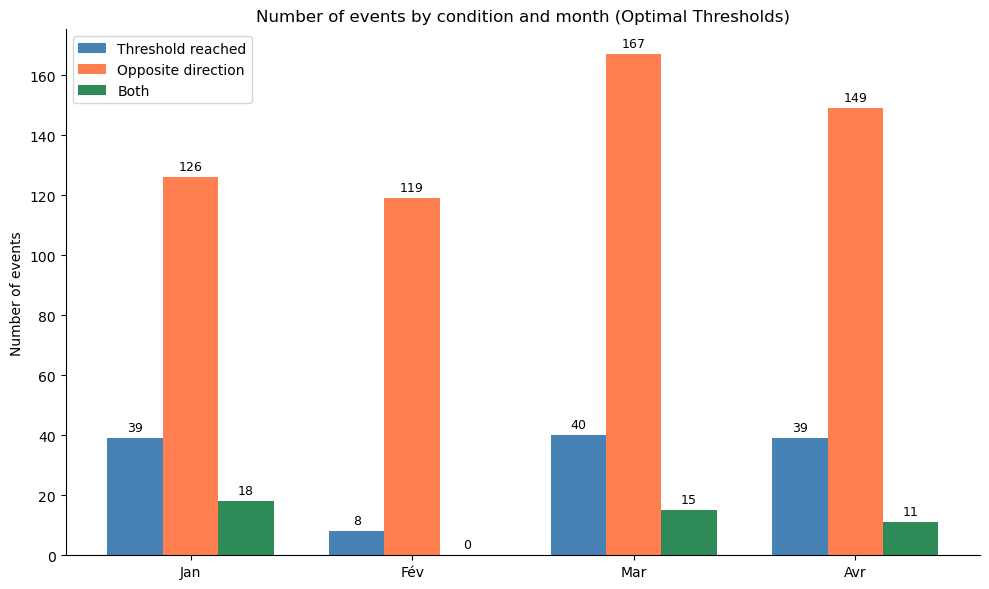

In [97]:
# Recalculate trades with optimal thresholds
trades_optimal = trades.copy()

imbalance_neg = trades_optimal['Total System Imbalance'] < 0
imbalance_pos = trades_optimal['Total System Imbalance'] > 0
is_sell = trades_optimal['Buy/Sell'].str.lower() == 's'
is_buy  = trades_optimal['Buy/Sell'].str.lower() == 'b'

prev_imbalance = trades_optimal['Total System Imbalance'].shift(1)
trades_optimal['Threshold reached'] = (prev_imbalance < optimal_threshold_low) | (prev_imbalance > optimal_threshold_high)

trades_optimal['Opposite direction'] = (imbalance_neg & is_sell) | (imbalance_pos & is_buy)

condition = trades_optimal['Threshold reached'] & trades_optimal['Opposite direction']
trades_optimal['Cost Swissgrid'] = np.where(condition, trades_optimal['Net'] * trades_optimal['Imbalance price'], np.nan)

trades_optimal['PnL vs Swissgrid'] = (trades_optimal['Cost Swissgrid'] - trades_optimal['Intraday cost'])*-1

months = {1: 'Jan', 2: 'Fév', 3: 'Mar', 4: 'Avr'}

monthly = trades_optimal.groupby(trades_optimal['Date Time'].dt.month).apply(lambda g: pd.Series({
    'Threshold reached': g['Threshold reached'].sum(),
    'Opposite direction': g['Opposite direction'].sum(),
    'Both': (g['Threshold reached'] & g['Opposite direction']).sum()
})).rename(index=months)

x = np.arange(len(monthly))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width, monthly['Threshold reached'], width, label='Threshold reached', color='steelblue')
b2 = ax.bar(x,         monthly['Opposite direction'],  width, label='Opposite direction',  color='coral')
b3 = ax.bar(x + width, monthly['Both'],                width, label='Both',                color='seagreen')

ax.bar_label(b1, padding=3, fontsize=9)
ax.bar_label(b2, padding=3, fontsize=9)
ax.bar_label(b3, padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(monthly.index)
ax.set_title("Number of events by condition and month (Optimal Thresholds)")
ax.set_ylabel("Number of events")
ax.legend()

plt.tight_layout()
plt.show()


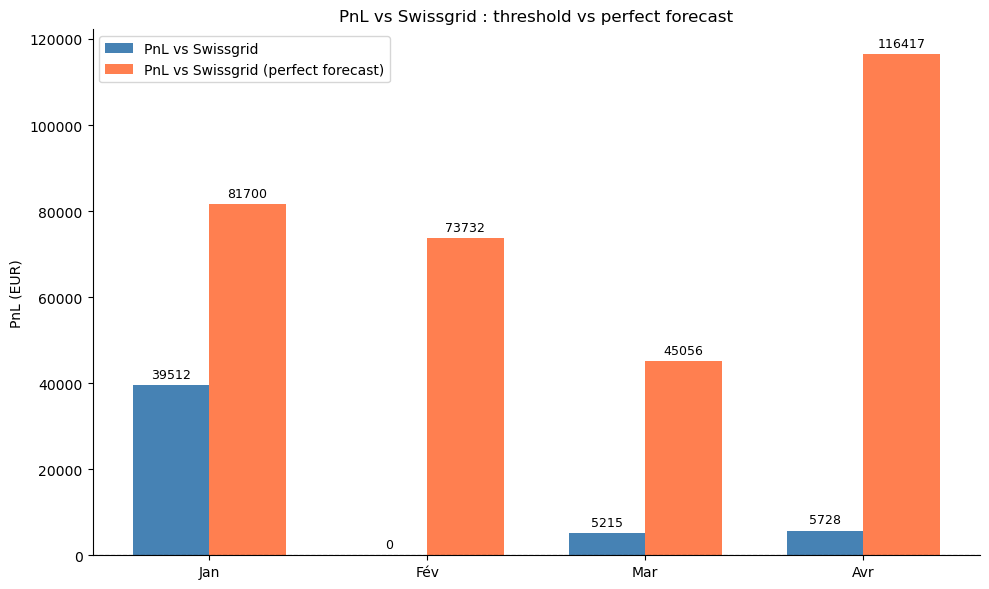

In [98]:
import matplotlib.pyplot as plt
import numpy as np

months = {1: 'Jan', 2: 'Fév', 3: 'Mar', 4: 'Avr'}

# Perfect forecast : Same sign next hour toujours True
condition_perfect = trades['EA price better'] & trades['Opposite direction']
trades['Cost Swissgrid perfect'] = np.where(condition_perfect, trades['Net'] * trades['Imbalance price'], np.nan)
trades['PnL vs Swissgrid perfect'] = trades['Cost Swissgrid perfect'] - trades['Intraday cost']

monthly = trades.groupby(trades['Date Time'].dt.month).agg(
    pnl=('PnL vs Swissgrid', lambda x: x.sum()),
    pnl_perfect=('PnL vs Swissgrid perfect', lambda x: x.sum()*-1)
).rename(index=months)

x = np.arange(len(monthly))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, monthly['pnl'],         width, label='PnL vs Swissgrid',                 color='steelblue')
b2 = ax.bar(x + width/2, monthly['pnl_perfect'], width, label='PnL vs Swissgrid (perfect forecast)', color='coral')

ax.bar_label(b1, fmt='%.0f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.0f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(monthly.index)
ax.set_title("PnL vs Swissgrid : threshold vs perfect forecast")
ax.set_ylabel("PnL (EUR)")
ax.legend()
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

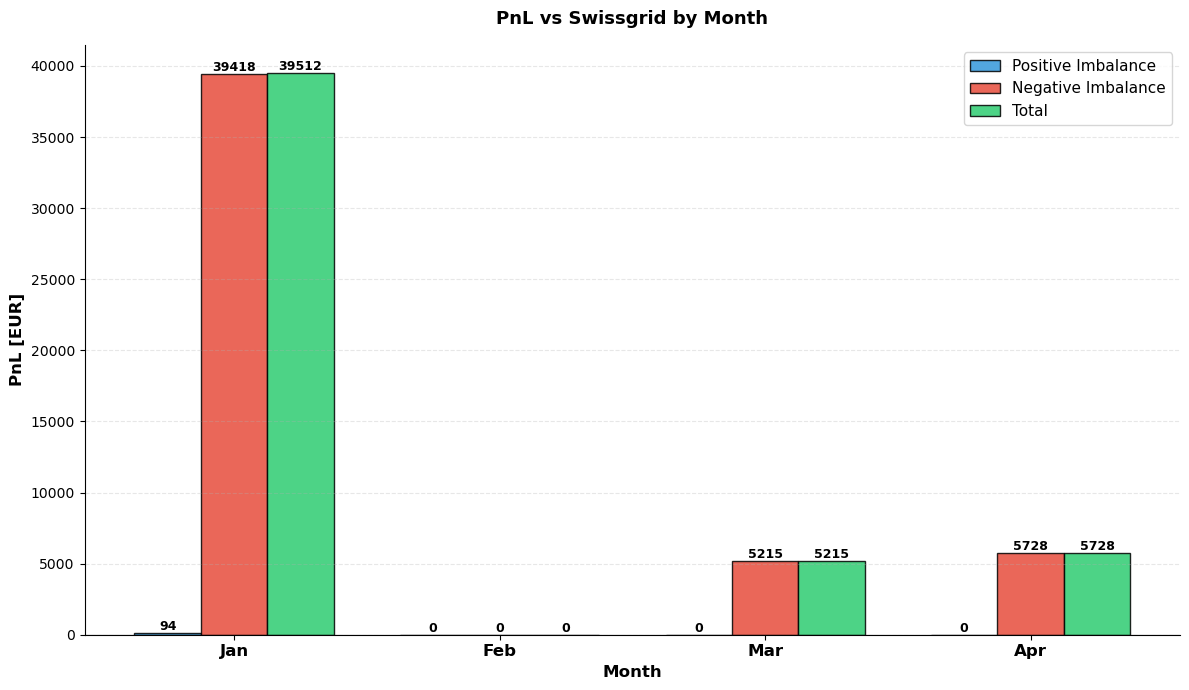


DETAILED SUMMARY: PnL vs Swissgrid by Month, Imbalance Direction, and PnL Sign
Month  Pos Imb - Neg PnL  Pos Imb - Pos PnL  Pos Imb - Total  Neg Imb - Neg PnL  Neg Imb - Pos PnL  Neg Imb - Total  Month Total
  Jan                0.0              94.14            94.14           -3632.04         43050.3950       39418.3550   39512.4950
  Feb                0.0               0.00             0.00               0.00             0.0000           0.0000       0.0000
  Mar                0.0               0.00             0.00            -101.64          5316.2175        5214.5775    5214.5775
  Apr                0.0               0.00             0.00               0.00          5728.2800        5728.2800    5728.2800

MONTHLY TOTALS
January        :     39512.49
February       :         0.00
March          :      5214.58
April          :      5728.28
GRAND TOTAL    :     50455.35


In [99]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare data by month and imbalance direction
months_list = [1, 2, 3, 4]
months_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April'}
months_short = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr'}

# Create data structure for plotting
plot_data = []
total_pnl_by_month = {}

for month in months_list:
    month_data = trades[trades['Date Time'].dt.month == month]
    
    # Split by imbalance direction
    pos_imb = month_data[month_data['Total System Imbalance'] > 0]
    neg_imb = month_data[month_data['Total System Imbalance'] < 0]
    
    # For positive imbalance
    pos_imb_neg_pnl = pos_imb[pos_imb['PnL vs Swissgrid'] < 0]['PnL vs Swissgrid'].sum()
    pos_imb_pos_pnl = pos_imb[pos_imb['PnL vs Swissgrid'] > 0]['PnL vs Swissgrid'].sum()
    pos_imb_total = pos_imb['PnL vs Swissgrid'].sum()
    
    # For negative imbalance
    neg_imb_neg_pnl = neg_imb[neg_imb['PnL vs Swissgrid'] < 0]['PnL vs Swissgrid'].sum()
    neg_imb_pos_pnl = neg_imb[neg_imb['PnL vs Swissgrid'] > 0]['PnL vs Swissgrid'].sum()
    neg_imb_total = neg_imb['PnL vs Swissgrid'].sum()
    
    # Total for month
    total_pnl_month = month_data['PnL vs Swissgrid'].sum()
    total_pnl_by_month[months_names[month]] = total_pnl_month
    
    plot_data.append({
        'Month': months_short[month],
        'Pos Imb - Neg PnL': pos_imb_neg_pnl,
        'Pos Imb - Pos PnL': pos_imb_pos_pnl,
        'Pos Imb - Total': pos_imb_total,
        'Neg Imb - Neg PnL': neg_imb_neg_pnl,
        'Neg Imb - Pos PnL': neg_imb_pos_pnl,
        'Neg Imb - Total': neg_imb_total,
        'Month Total': total_pnl_month
    })

df_plot = pd.DataFrame(plot_data)

# Create single plot with months on x-axis
fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data for grouped bars - months on x-axis
months_short_list = df_plot['Month'].tolist()
x_months = np.arange(len(months_short_list))
width = 0.25

colors_pos_imb = '#3498db'   # Blue - Positive Imbalance
colors_neg_imb = '#e74c3c'   # Red - Negative Imbalance
colors_total = '#2ecc71'     # Green - Total

# Plot bars for each category within each month
categories_labels = ['Positive Imbalance', 'Negative Imbalance', 'Total']

bar_positions = [
    [-width, colors_pos_imb],   # Pos Imb - Total
    [0, colors_neg_imb],        # Neg Imb - Total
    [width, colors_total]       # Total
]

# Create bars
for idx, (offset, color) in enumerate(bar_positions):
    values = []
    for month_idx in range(len(df_plot)):
        month_row = df_plot.iloc[month_idx]
        if idx == 0:
            values.append(month_row['Pos Imb - Total'])
        elif idx == 1:
            values.append(month_row['Neg Imb - Total'])
        else:
            values.append(month_row['Month Total'])
    
    bars = ax.bar(x_months + offset, values, width, label=categories_labels[idx], 
                  color=color, alpha=0.85, edgecolor='black', linewidth=1)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom' if height >= 0 else 'top', 
                fontsize=9, fontweight='bold')

ax.set_xticks(x_months)
ax.set_xticklabels(months_short_list, fontsize=12, fontweight='bold')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('PnL [EUR]', fontsize=12, fontweight='bold')
ax.set_title('PnL vs Swissgrid by Month', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()

# Print detailed summary
print("\n" + "="*100)
print("DETAILED SUMMARY: PnL vs Swissgrid by Month, Imbalance Direction, and PnL Sign")
print("="*100)
print(df_plot.to_string(index=False))

print("\n" + "="*100)
print("MONTHLY TOTALS")
print("="*100)
for month_name, total in total_pnl_by_month.items():
    print(f"{month_name:15s}: {total:12.2f}")
print(f"{'GRAND TOTAL':15s}: {sum(total_pnl_by_month.values()):12.2f}")


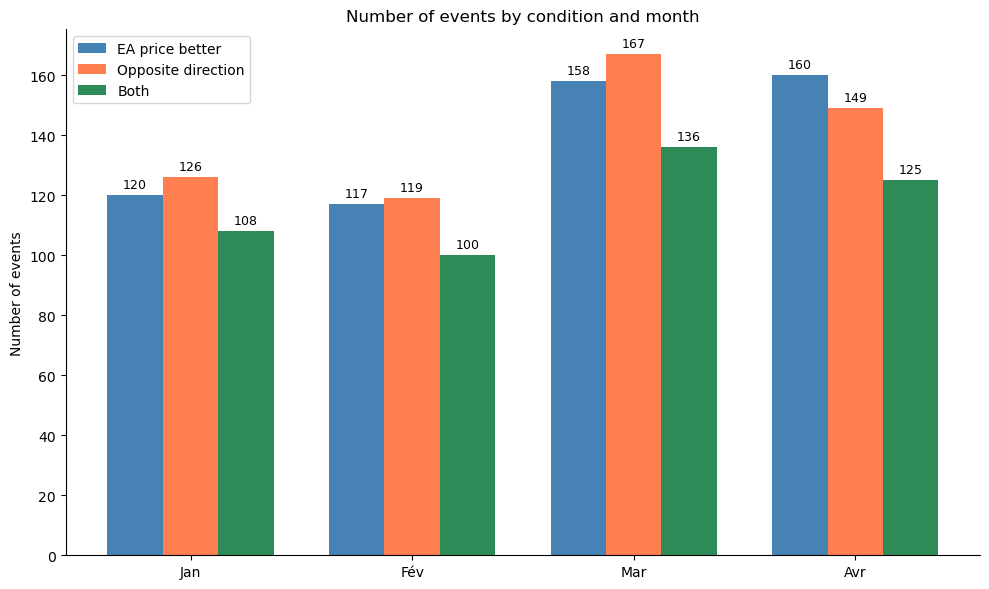

In [100]:
import matplotlib.pyplot as plt
import numpy as np

months = {1: 'Jan', 2: 'Fév', 3: 'Mar', 4: 'Avr'}

monthly = trades.groupby(trades['Date Time'].dt.month).apply(lambda g: pd.Series({
    'EA price better': g['EA price better'].sum(),
    'Opposite direction': g['Opposite direction'].sum(),
    'Both': (g['EA price better'] & g['Opposite direction']).sum()
})).rename(index=months)

x = np.arange(len(monthly))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width, monthly['EA price better'], width, label='EA price better', color='steelblue')
b2 = ax.bar(x,         monthly['Opposite direction'],  width, label='Opposite direction',  color='coral')
b3 = ax.bar(x + width, monthly['Both'],                width, label='Both',                color='seagreen')

ax.bar_label(b1, padding=3, fontsize=9)
ax.bar_label(b2, padding=3, fontsize=9)
ax.bar_label(b3, padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(monthly.index)
ax.set_title("Number of events by condition and month")
ax.set_ylabel("Number of events")
ax.legend()

plt.tight_layout()
plt.show()

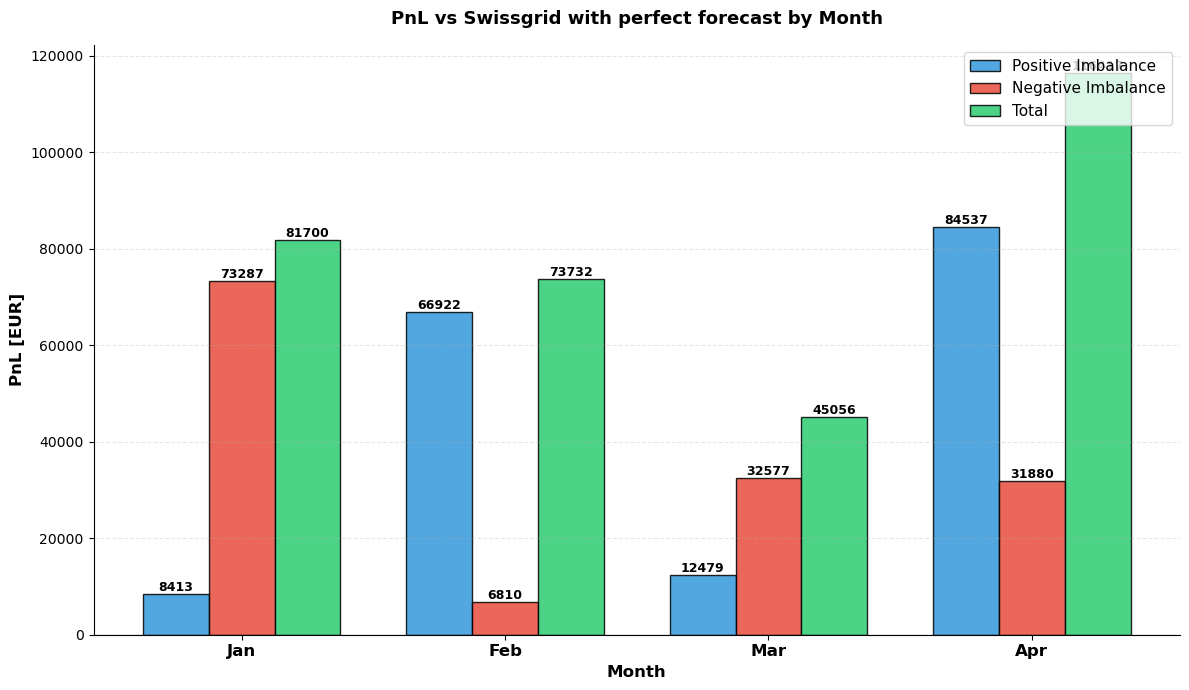


DETAILED SUMMARY: PnL vs Swissgrid with perfect forecast by Month, Imbalance Direction, and PnL Sign
Month  Pos Imb - Neg PnL  Pos Imb - Pos PnL  Pos Imb - Total  Neg Imb - Neg PnL  Neg Imb - Pos PnL  Neg Imb - Total  Month Total
  Jan                0.0          8412.8250        8412.8250                0.0         73287.3525       73287.3525   81700.1775
  Feb                0.0         66921.5825       66921.5825                0.0          6810.0225        6810.0225   73731.6050
  Mar                0.0         12479.2175       12479.2175                0.0         32576.5175       32576.5175   45055.7350
  Apr                0.0         84537.4025       84537.4025                0.0         31879.5650       31879.5650  116416.9675

MONTHLY TOTALS
January        :     81700.18
February       :     73731.60
March          :     45055.74
April          :    116416.97
Pos Imb Total  :    172351.03
Neg Imb Total  :    144553.46
GRAND TOTAL    :    316904.48


In [132]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare data by month and imbalance direction
months_list = [1, 2, 3, 4]
months_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April'}
months_short = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr'}

# Create data structure for plotting
plot_data = []
total_pnl_by_month = {}

for month in months_list:
    month_data = trades[trades['Date Time'].dt.month == month]
    
    # Split by imbalance direction
    pos_imb = month_data[month_data['Total System Imbalance'] > 0]
    neg_imb = month_data[month_data['Total System Imbalance'] < 0]
    
    # For positive imbalance
    pos_imb_neg_pnl = pos_imb[pos_imb['PnL vs Swissgrid with perfect forecast'] < 0]['PnL vs Swissgrid with perfect forecast'].sum()
    pos_imb_pos_pnl = pos_imb[pos_imb['PnL vs Swissgrid with perfect forecast'] > 0]['PnL vs Swissgrid with perfect forecast'].sum()
    pos_imb_total = pos_imb['PnL vs Swissgrid with perfect forecast'].sum()
    
    # For negative imbalance
    neg_imb_neg_pnl = neg_imb[neg_imb['PnL vs Swissgrid with perfect forecast'] < 0]['PnL vs Swissgrid with perfect forecast'].sum()
    neg_imb_pos_pnl = neg_imb[neg_imb['PnL vs Swissgrid with perfect forecast'] > 0]['PnL vs Swissgrid with perfect forecast'].sum()
    neg_imb_total = neg_imb['PnL vs Swissgrid with perfect forecast'].sum()
    
    # Total for month
    total_pnl_month = month_data['PnL vs Swissgrid with perfect forecast'].sum()
    total_pnl_by_month[months_names[month]] = total_pnl_month
    
    plot_data.append({
        'Month': months_short[month],
        'Pos Imb - Neg PnL': pos_imb_neg_pnl,
        'Pos Imb - Pos PnL': pos_imb_pos_pnl,
        'Pos Imb - Total': pos_imb_total,
        'Neg Imb - Neg PnL': neg_imb_neg_pnl,
        'Neg Imb - Pos PnL': neg_imb_pos_pnl,
        'Neg Imb - Total': neg_imb_total,
        'Month Total': total_pnl_month
    })

df_plot = pd.DataFrame(plot_data)

# Create single plot with months on x-axis
fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data for grouped bars - months on x-axis
months_short_list = df_plot['Month'].tolist()
x_months = np.arange(len(months_short_list))
width = 0.25

colors_pos_imb = '#3498db'   # Blue - Positive Imbalance
colors_neg_imb = '#e74c3c'   # Red - Negative Imbalance
colors_total = '#2ecc71'     # Green - Total

# Plot bars for each category within each month
categories_labels = ['Positive Imbalance', 'Negative Imbalance', 'Total']

bar_positions = [
    [-width, colors_pos_imb],   # Pos Imb - Total
    [0, colors_neg_imb],        # Neg Imb - Total
    [width, colors_total]       # Total
]

# Create bars
for idx, (offset, color) in enumerate(bar_positions):
    values = []
    for month_idx in range(len(df_plot)):
        month_row = df_plot.iloc[month_idx]
        if idx == 0:
            values.append(month_row['Pos Imb - Total'])
        elif idx == 1:
            values.append(month_row['Neg Imb - Total'])
        else:
            values.append(month_row['Month Total'])
    
    bars = ax.bar(x_months + offset, values, width, label=categories_labels[idx], 
                  color=color, alpha=0.85, edgecolor='black', linewidth=1)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom' if height >= 0 else 'top', 
                fontsize=9, fontweight='bold')

ax.set_xticks(x_months)
ax.set_xticklabels(months_short_list, fontsize=12, fontweight='bold')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('PnL [EUR]', fontsize=12, fontweight='bold')
ax.set_title('PnL vs Swissgrid with perfect forecast by Month', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()

# Print detailed summary
print("\n" + "="*100)
print("DETAILED SUMMARY: PnL vs Swissgrid with perfect forecast by Month, Imbalance Direction, and PnL Sign")
print("="*100)
print(df_plot.to_string(index=False))

print("\n" + "="*100)
print("MONTHLY TOTALS")
print("="*100)
for month_name, total in total_pnl_by_month.items():
    print(f"{month_name:15s}: {total:12.2f}")

print(f"{'Pos Imb Total':15s}: {df_plot['Pos Imb - Total'].sum():12.2f}")
print(f"{'Neg Imb Total':15s}: {df_plot['Neg Imb - Total'].sum():12.2f}")

print(f"{'GRAND TOTAL':15s}: {sum(total_pnl_by_month.values()):12.2f}")
